
<div style="border-radius:10px;
            border : #015a2c solid;
            background-color:#D7D9DB;
           font-size:110%;
           letter-spacing:0.5px;
            text-align: center">
​
<center><h1 style="padding: 25px 0px; color:#015a4c; font-weight: bold; font-family: Cursive">
Amit Project for Data Science Module <br><br>💡💡💡💡💡 <br><br> DEPI_BS_DS_R3  </h1></center>
<center><h3 style="padding-bottom: 25px; color:#025b2c; font-weight: bold; font-style:italic; font-family: Cursive">
Using Project: Trip data Ford go bike  </h3></center>     
​
</div>

# Part I - (Dataset Exploration for Ford GoBike)

### worked by (Your Name/2025 )

## Introduction

.

> **Let's introduce our dataset:**


======================================

.

**This data set information was produced from `Ford GoBike` System** the information in it talked about individual rides that were made in a bike-sharing system for covering San Francisco Bay area.** 

.




> ## And here are the main exploring questions 



   **==================================================**



- What is the structure of your dataset?


- What are the main interesting features in the dataset?


- What features in the dataset supported my investigation for these interesting features?




.

> ### Also here are the investigative questions classified into three types



   **================================================**
   
   


###  <a href='#011'> Univariate Exploration</a> 

- <a href='#1'> 1 ) . What is the distribution of `User type`?</a>  
- <a href='#2'> 2 ) . What is the distribution for the `bike share users on all Trips`?</a>  
- <a href='#3'> 3 ) . What is the distribution for users' `ages`?</a>  
- <a href='#4'> 4 ) . Do the users' ages have `outlier` values?</a>
- <a href='#5'> 5 ) . What is the distribution for the trip duration in `minutes`? </a>
- <a href='#6'> 6) . What is the distribution for `member_gender`? </a>
- <a href='#7'> 7) . What is the distribution for the trip duration in `Hours`?  </a>




##  <a href='#111'> Bivariate Exploration</a> 


- <a href='#8'> 8 ) . What the `average duration` of trip for the categories of `user type`? </a>
- <a href='#9'> 9 ) . How long is the duration of the trip for `each gender` in `minutes`? </a>
- <a href='#10'> 10 ) . How long is the duration of the trip for each `user_type` in `minutes`?  </a>
- <a href='#11'> 11 ) . How the user distribution depending on their `Age` and `user_type` ?</a>
- <a href='#12'>12 ). How the user distribution depending on their `Age` and `member_gender` ?  </a>


##  <a href='#1111'> Multivariate Exploration</a> 


- <a href='#13'> 13 ) . What is the Correlation between `each` variable in the dataset?</a>  
- <a href='#14'> 14 ) . What is the Correlation between `specific numeric variables` in the dataset?</a>  
- <a href='#15'> 15 ) . What is the  Correlation between `data_stat` variables in the dataset?</a>  


##  <a href='#1100'> Conclusions </a> 





# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Import Libraries</p>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt

import seaborn as sb



In [2]:
# Load my dataset using pandas Dataframe

data = pd.read_csv('201902-fordgobike-tripdata.csv')

In [3]:
# here we make overview in high-level for data shape and composition
data.info()


data.shape

<class 'pandas.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  str    
 2   end_time                 183412 non-null  str    
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  str    
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  str    
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  str    
 13  member_birth_year        175147 non-null  float64
 14  member_gender  

(183412, 16)

In [4]:
## check each var  datatype 

for col in data.columns:
    
    unique_values = data[col].nunique()
    
    print(f"{col}: {data[col].dtype}")

duration_sec: int64
start_time: str
end_time: str
start_station_id: float64
start_station_name: str
start_station_latitude: float64
start_station_longitude: float64
end_station_id: float64
end_station_name: str
end_station_latitude: float64
end_station_longitude: float64
bike_id: int64
user_type: str
member_birth_year: float64
member_gender: str
bike_share_for_all_trip: str


In [5]:
## I display 15 rows to understand the content values more 
data.head(15)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
5,1793,2019-02-28 23:49:58.6320,2019-03-01 00:19:51.7600,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No
6,1147,2019-02-28 23:55:35.1040,2019-03-01 00:14:42.5880,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No
7,1615,2019-02-28 23:41:06.7660,2019-03-01 00:08:02.7560,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No
8,1570,2019-02-28 23:41:48.7900,2019-03-01 00:07:59.7150,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No
9,1049,2019-02-28 23:49:47.6990,2019-03-01 00:07:17.0250,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,-122.421339,6488,Subscriber,1992.0,Male,No


In [6]:
#this code for transforming datatype of columns to more appropriate datatypes for analysis
for col in data.columns:
    
    unique_values = data[col].nunique()
    
    print(f"{col}: {data[col].dtype}, unique values: {unique_values}")
category_columns = ['user_type', 'member_gender', 'bike_share_for_all_trip']
for col in data.columns:
    if col in category_columns:
        data[col] = data[col].astype('category')
    elif data[col].dtype == 'str':
        data[col] = data[col].astype('object')

duration_sec: int64, unique values: 4752
start_time: str, unique values: 183401
end_time: str, unique values: 183397
start_station_id: float64, unique values: 329
start_station_name: str, unique values: 329
start_station_latitude: float64, unique values: 334
start_station_longitude: float64, unique values: 335
end_station_id: float64, unique values: 329
end_station_name: str, unique values: 329
end_station_latitude: float64, unique values: 335
end_station_longitude: float64, unique values: 335
bike_id: int64, unique values: 4646
user_type: str, unique values: 2
member_birth_year: float64, unique values: 75
member_gender: str, unique values: 3
bike_share_for_all_trip: str, unique values: 2


In [7]:
# descriptive statistics for numeric variables
data.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183412.000000,183215.000000,183412.000000,183412.000000,183215.000000,183412.000000,183412.000000,183412.000000,175147.000000
mean,726.078435,138.590427,37.771223,-122.352664,136.249123,37.771427,-122.352250,4472.906375,1984.806437
std,1794.389780,111.778864,0.099581,0.117097,111.515131,0.099490,0.116673,1664.383394,10.116689
min,61.000000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000




> ### What is the structure of your dataset?





- The structure of the dataset contains  16 columns and 183416 rows.
 
 
- Most variables are ...... in nature , and here are **dtypes summary :**

   duration_sec: int64
start_time: str
end_time: str
start_station_id: float64
start_station_name: str
start_station_latitude: float64
start_station_longitude: float64
end_station_id: float64
end_station_name: str
end_station_latitude: float64
end_station_longitude: float64
bike_id: int64
user_type: str
member_birth_year: float64
member_gender: str
bike_share_for_all_trip: str
        



> ### What are the main interesting features in the dataset?




 **We got three main feature areas which are :**
 
 
 
 
- 
 
 
 
- 
 
  
 
  
- 




> ### What features in the dataset supported my investigation for these interesting features?



- 



- 



- 



-




- 




##  More Exploring ideas to begin my investigation

In [8]:
#This code for describing statistical data ideas in a more organized and readable table
data.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
duration_sec,183412.0,726.078435,1794.389780,61.000000,325.000000,514.000000,796.000000,85444.000000
start_station_id,183215.0,138.590427,111.778864,3.000000,47.000000,104.000000,239.000000,398.000000
start_station_latitude,183412.0,37.771223,0.099581,37.317298,37.770083,37.780760,37.797280,37.880222
start_station_longitude,183412.0,-122.352664,0.117097,-122.453704,-122.412408,-122.398285,-122.286533,-121.874119
end_station_id,183215.0,136.249123,111.515131,3.000000,44.000000,100.000000,235.000000,398.000000
end_station_latitude,183412.0,37.771427,0.099490,37.317298,37.770407,37.781010,37.797320,37.880222
end_station_longitude,183412.0,-122.352250,0.116673,-122.453704,-122.411726,-122.398279,-122.288045,-121.874119
bike_id,183412.0,4472.906375,1664.383394,11.000000,3777.000000,4958.000000,5502.000000,6645.000000
member_birth_year,175147.0,1984.806437,10.116689,1878.000000,1980.000000,1987.000000,1992.000000,2001.000000


In [9]:
# display the information about each column
data.info()



<class 'pandas.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   duration_sec             183412 non-null  int64   
 1   start_time               183412 non-null  object  
 2   end_time                 183412 non-null  object  
 3   start_station_id         183215 non-null  float64 
 4   start_station_name       183215 non-null  object  
 5   start_station_latitude   183412 non-null  float64 
 6   start_station_longitude  183412 non-null  float64 
 7   end_station_id           183215 non-null  float64 
 8   end_station_name         183215 non-null  object  
 9   end_station_latitude     183412 non-null  float64 
 10  end_station_longitude    183412 non-null  float64 
 11  bike_id                  183412 non-null  int64   
 12  user_type                183412 non-null  category
 13  member_birth_year        175147 non-null  float64 
 14 

## <mark>The above result show some missing values exist in some columns So let's display them </mark>

In [10]:
#yOUR CODES
for col in data.columns:
    print(f"{col}: {data[col].isnull().sum()} null values")

duration_sec: 0 null values
start_time: 0 null values
end_time: 0 null values
start_station_id: 197 null values
start_station_name: 197 null values
start_station_latitude: 0 null values
start_station_longitude: 0 null values
end_station_id: 197 null values
end_station_name: 197 null values
end_station_latitude: 0 null values
end_station_longitude: 0 null values
bike_id: 0 null values
user_type: 0 null values
member_birth_year: 8265 null values
member_gender: 8265 null values
bike_share_for_all_trip: 0 null values




> ## <mark>The result above shows many missing data </mark>



###  To fix this issue You will fill these values with ........... for numeric and ......for categorical

In [11]:
# trying to fill missing values in my datset using for loop 

# Birth year
data['member_birth_year'] = data['member_birth_year'].fillna(
    data['member_birth_year'].median()
)

# Station names
data['start_station_name'] = data['start_station_name'].fillna('Unknown')
data['end_station_name'] = data['end_station_name'].fillna('Unknown')
data['start_station_id'] = data['start_station_id'].fillna(-1)
data['end_station_id'] = data['end_station_id'].fillna(-1)


In [12]:
#check the Nulls 
print(data.isnull().sum())

duration_sec                  0
start_time                    0
end_time                      0
start_station_id              0
start_station_name            0
start_station_latitude        0
start_station_longitude       0
end_station_id                0
end_station_name              0
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year             0
member_gender              8265
bike_share_for_all_trip       0
dtype: int64


### **And with a proper category for other (member gender)**

In [13]:
##  still got a missing value in the member_gender, so let's explore this column more 

print(data.member_gender.head(15))

0       Male
1        NaN
2       Male
3      Other
4       Male
5       Male
6     Female
7       Male
8      Other
9       Male
10    Female
11      Male
12      Male
13       NaN
14      Male
Name: member_gender, dtype: category
Categories (3, str): ['Female', 'Male', 'Other']


In [14]:
# fill  dataset with missing values.
data['member_gender'] = data['member_gender'].cat.add_categories(['Unknown'])
data['member_gender'] = data['member_gender'].fillna('Unknown')



In [15]:
print(data.member_gender.head(15))

0        Male
1     Unknown
2        Male
3       Other
4        Male
5        Male
6      Female
7        Male
8       Other
9        Male
10     Female
11       Male
12       Male
13    Unknown
14       Male
Name: member_gender, dtype: category
Categories (4, str): ['Female', 'Male', 'Other', 'Unknown']


In [16]:
## check my result above 
print(data.isnull().sum())


duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64


> ## <mark>The result above shows that we deal with all missing data </mark>

### Now let's check duplicate value

In [17]:
##  check duplicate in dataset
print(f"Number of duplicate rows: {data.duplicated().sum()}")


Number of duplicate rows: 0


> ##If Not significant duplicated , so won't clean it 


### Now let's check the category columns to make more cleaning dataset 

In [18]:
### check the category columns that included object
print(data.select_dtypes(include=['category', 'object']).nunique())

start_time                 183401
end_time                   183397
start_station_name            330
end_station_name              330
user_type                       2
member_gender                   4
bike_share_for_all_trip         2
dtype: int64


 > ## From all previous results above I found  :
 
 
 
 **=========================================================**
 
 

> 1 ) **unique Value** as in ((`member_gender`)) : Not significant , so won't clean it



> 2 ) **Incorrect data type** as in (( `user_type` &&	`member_gender`)) :  significant change , so I need to clean it.


> 3 ) **Good factor** for marketing work as in ((`member_birth_year`)) : so I need to clean it.

In [19]:
##  step  2 ) Incorrect data type as in (( `user_type` &&	`member_gender`)) :  significant change , so  need to clean it.



In [20]:
## check your work 
print("member_gender",{data['member_gender'].dtypes},'user_type',[data['user_type'].dtypes])


member_gender {CategoricalDtype(categories=['Female', 'Male', 'Other', 'Unknown'], ordered=False, categories_dtype=str)} user_type [CategoricalDtype(categories=['Customer', 'Subscriber'], ordered=False, categories_dtype=str)]


In [21]:
data['start_time']

0         2019-02-28 17:32:10.1450
1         2019-02-28 18:53:21.7890
2         2019-02-28 12:13:13.2180
3         2019-02-28 17:54:26.0100
4         2019-02-28 23:54:18.5490
                    ...           
183407    2019-02-01 00:04:49.7240
183408    2019-02-01 00:05:34.7440
183409    2019-02-01 00:06:05.5490
183410    2019-02-01 00:05:34.3600
183411    2019-02-01 00:00:20.6360
Name: start_time, Length: 183412, dtype: object

In [22]:
## step 3 ) Good factor for marketing work as in ((`member_birth_year`)) : so need to clean it.
## To know the target audience's age and serve on them

# create a column for users' age depending on the current year
data['start_time'] = pd.to_datetime(data['start_time'])
data['end_time']   = pd.to_datetime(data['end_time'])
data['member_age'] = data['start_time'].dt.year - data['member_birth_year']

In [23]:
## check your work 

data[['member_birth_year', 'member_age']].head(15)

,member_birth_year,member_age
0,1984.0,35.0
1,1987.0,32.0
2,1972.0,47.0
3,1989.0,30.0
4,1974.0,45.0
5,1959.0,60.0
6,1983.0,36.0
7,1989.0,30.0
8,1988.0,31.0
9,1992.0,27.0


In [24]:
## change the new column age data type from float to int

data['member_age'] = data['member_age'].astype('int64')

In [25]:
## create a function to know the average users ages
def average_age(data):
    return data['member_age'].mean()


In [26]:
## another important factor to offer  marketing services is the trip duration time 

## need to change the time from second to minute to be more usable

data['duration_min'] = data['duration_sec'] / 60
data['duration_min'] = data['duration_min'].astype('int64')


In [27]:
## I need to change the time from second to Houre  to be more usable

data['duration_hour'] = data['duration_sec'] / 3600

In [28]:
## check your work 
data[['duration_sec', 'duration_min', 'duration_hour']].head(15)


,duration_sec,duration_min,duration_hour
0,52185,869,14.495833
1,42521,708,11.811389
2,61854,1030,17.181667
3,36490,608,10.136111
4,1585,26,0.440278
5,1793,29,0.498056
6,1147,19,0.318611
7,1615,26,0.448611
8,1570,26,0.436111
9,1049,17,0.291389



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Univariate Exploration</p>
# <a id="011"> Univariate Exploration</a>



> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.




# <a id="1"> 1 ) . What is the distribution for User type?</a>

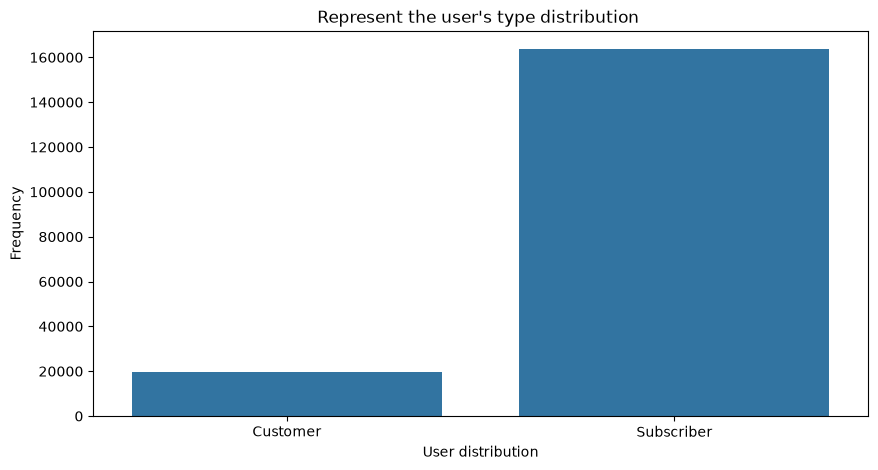

In [29]:
## I will import seaborn library to support me in making visualizations 

import seaborn as sns
plt.figure(figsize = (10,5))

plot = sns.countplot(data=data, x='user_type')

plt.xlabel('User distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's type distribution ")

plt.show()

> ### <mark>Your analsys and exploration here </mark>

# <a id="2"> 2 ) What is the distribution for the bike share users on all Trips?</a>

> ### <mark>Your analsys and exploration here </mark>

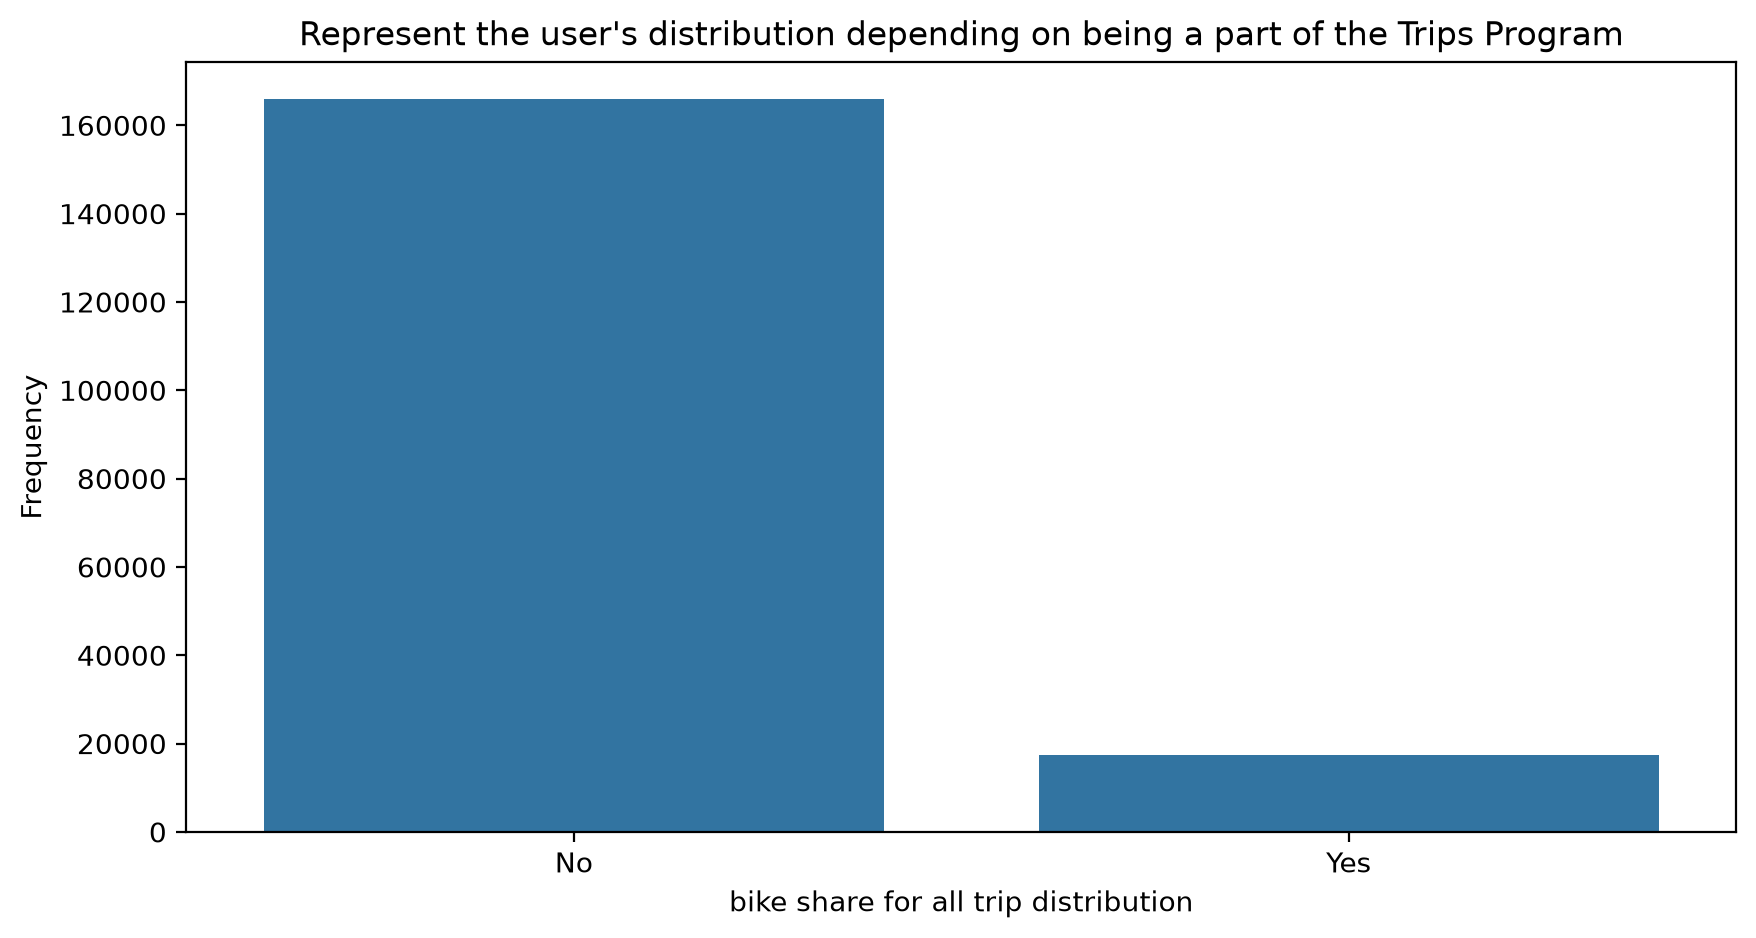

In [30]:

plt.figure(figsize = (10,5), dpi = 200)

plot = sns.countplot(data=data, x='bike_share_for_all_trip')

plt.xlabel('bike share for all trip distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on being a part of the Trips Program")

plt.show()

# <a id="3"> 3 ) What is the distribution for users' ages? </a>

> ### <mark>Your analsys and exploration here </mark>

In [31]:
print(data['member_age'].describe())

count    183412.000000
mean         34.094716
std           9.896585
min          18.000000
25%          27.000000
50%          32.000000
75%          38.000000
max         141.000000
Name: member_age, dtype: float64


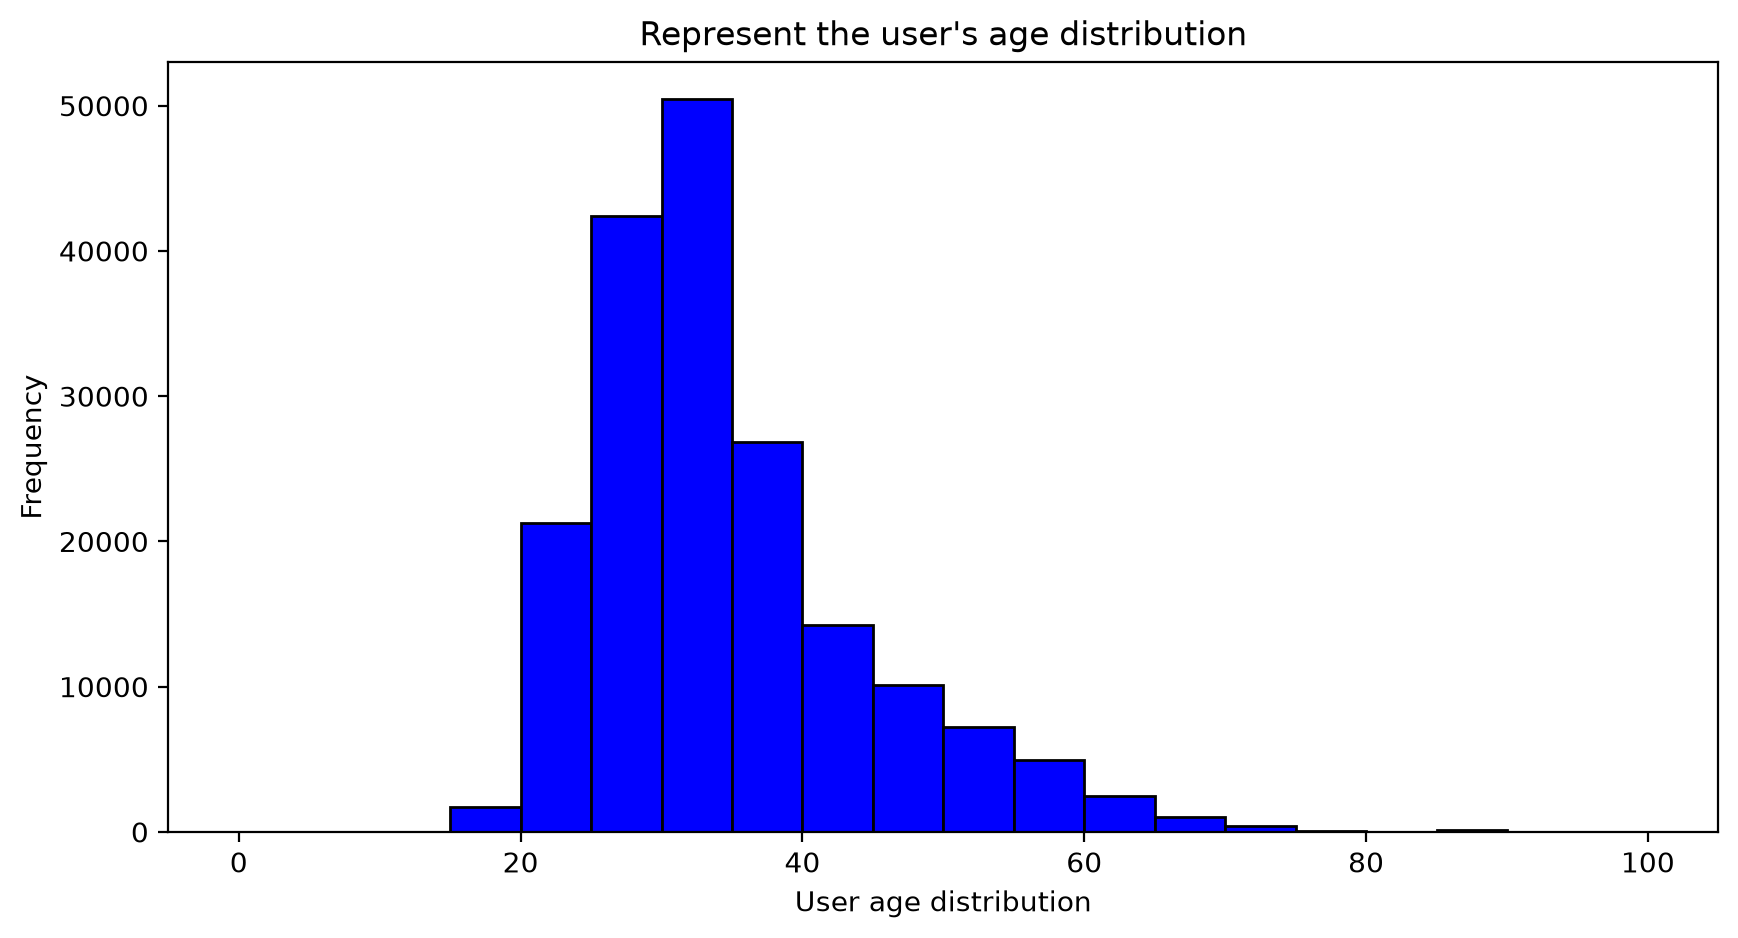

In [32]:

plt.figure(figsize = (10,5), dpi = 200)

plot = plt.hist(data['member_age'], bins=20, range=(0,100), color='blue', edgecolor='black')

plt.xlabel('User age distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's age distribution")

plt.show()


# <a id="4">  4 ) . Do the users' ages have outlier values?</a>


> ### <mark>Your analsys and exploration here </mark>

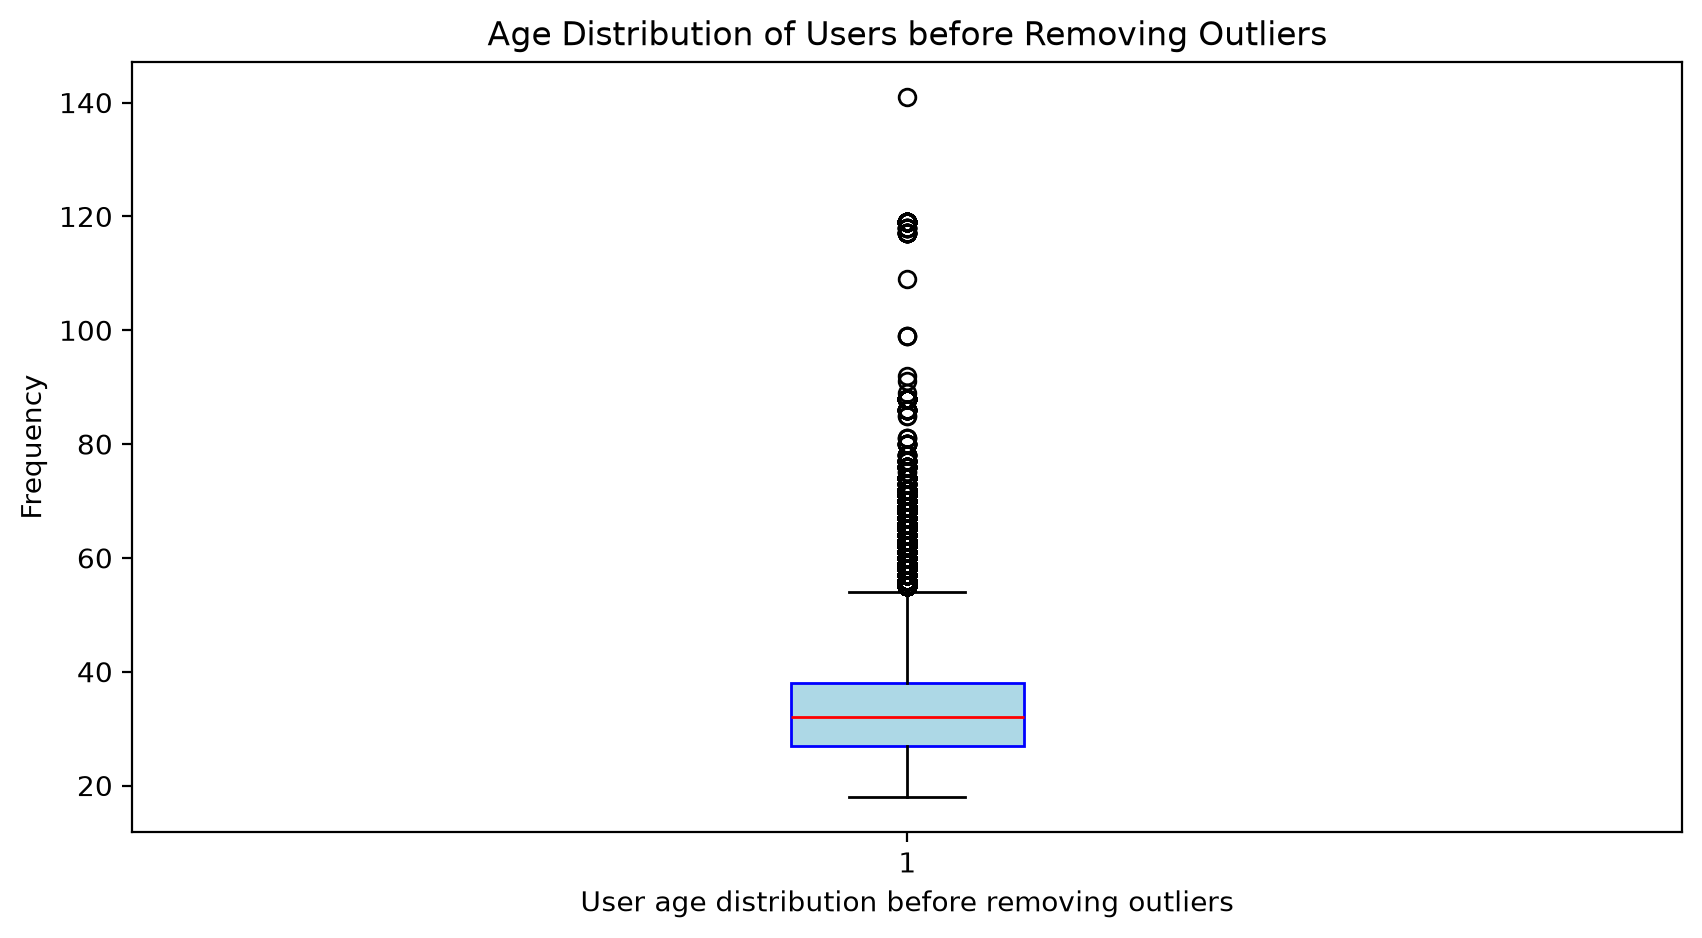

In [33]:
plt.figure(figsize = (10,5), dpi = 200)
plot = plt.boxplot(data['member_age'], patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'), medianprops=dict(color='red'))
plt.xlabel('User age distribution before removing outliers')
plt.ylabel('Frequency')
plt.title('Age Distribution of Users before Removing Outliers')
plt.show()

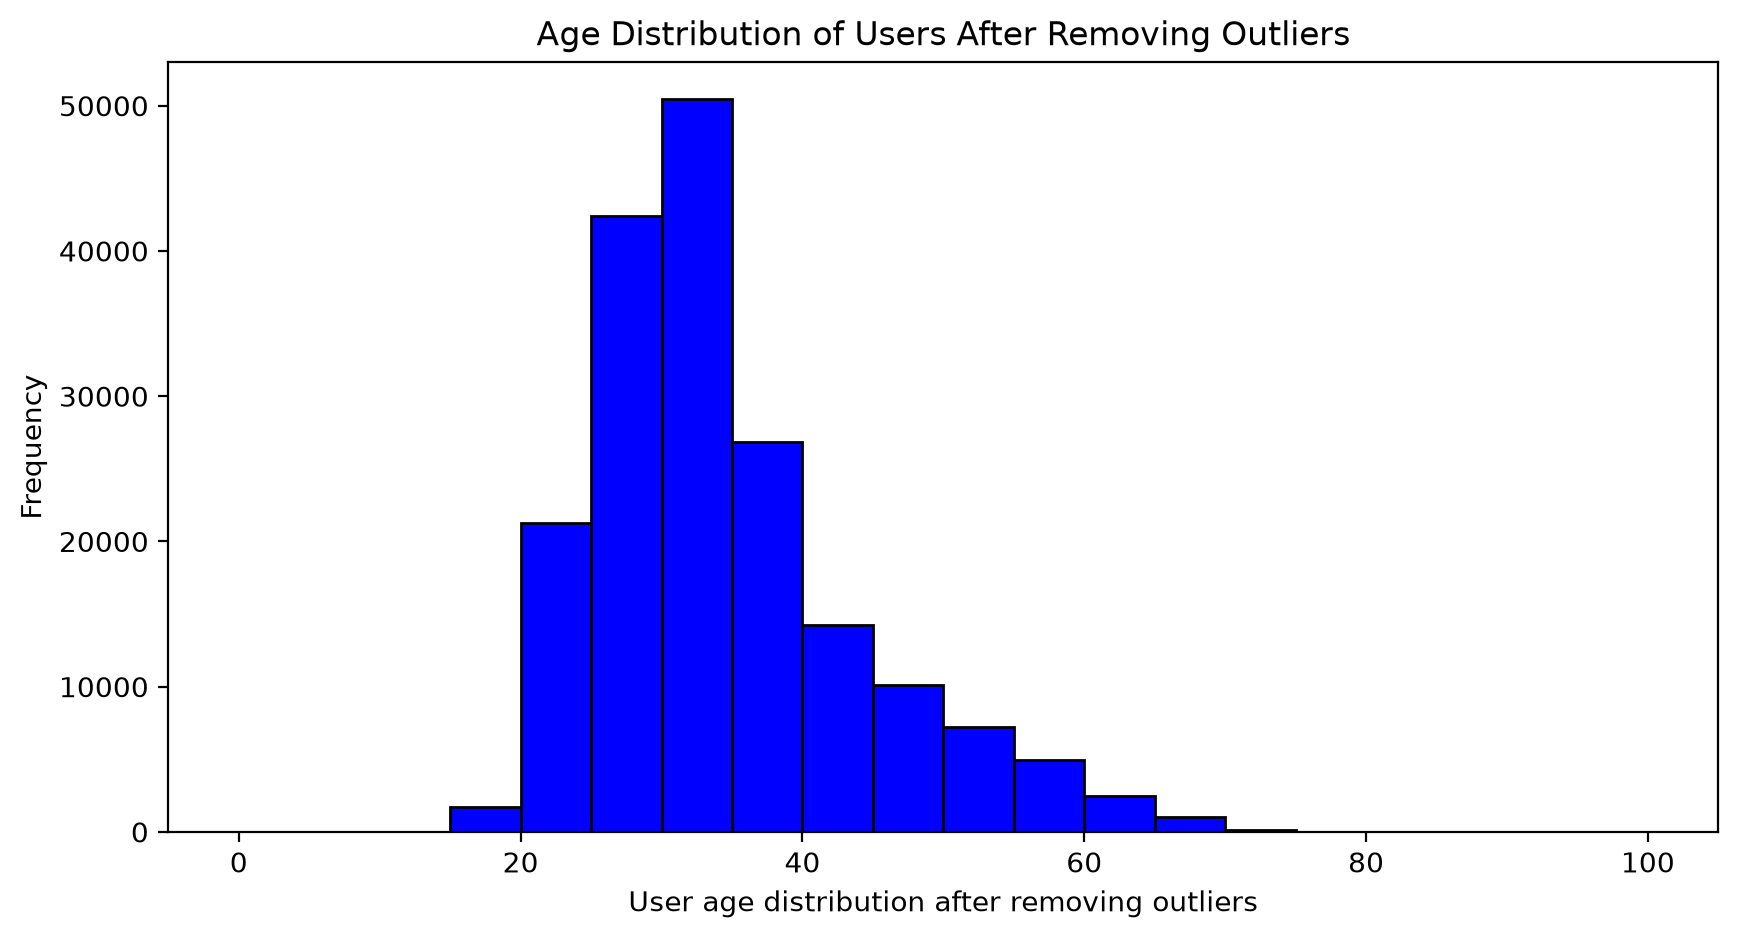

In [34]:
q1=data['member_age'].quantile(0.25)
q2=data['member_age'].quantile(0.5)
q3=data['member_age'].quantile(0.75)
iqr=q3-q1
upper_limit=q3+3*iqr
lower_limit=q1-3*iqr
mask = data['member_age'].between(lower_limit, upper_limit)
data = data[mask].copy()
plt.figure(figsize = (10,5), dpi = 200)
plot = plt.hist(data['member_age'], bins=20,range=(0,100), color='blue', edgecolor='black')
plt.xlabel('User age distribution after removing outliers')
plt.ylabel('Frequency')
plt.title('Age Distribution of Users After Removing Outliers')
plt.show()

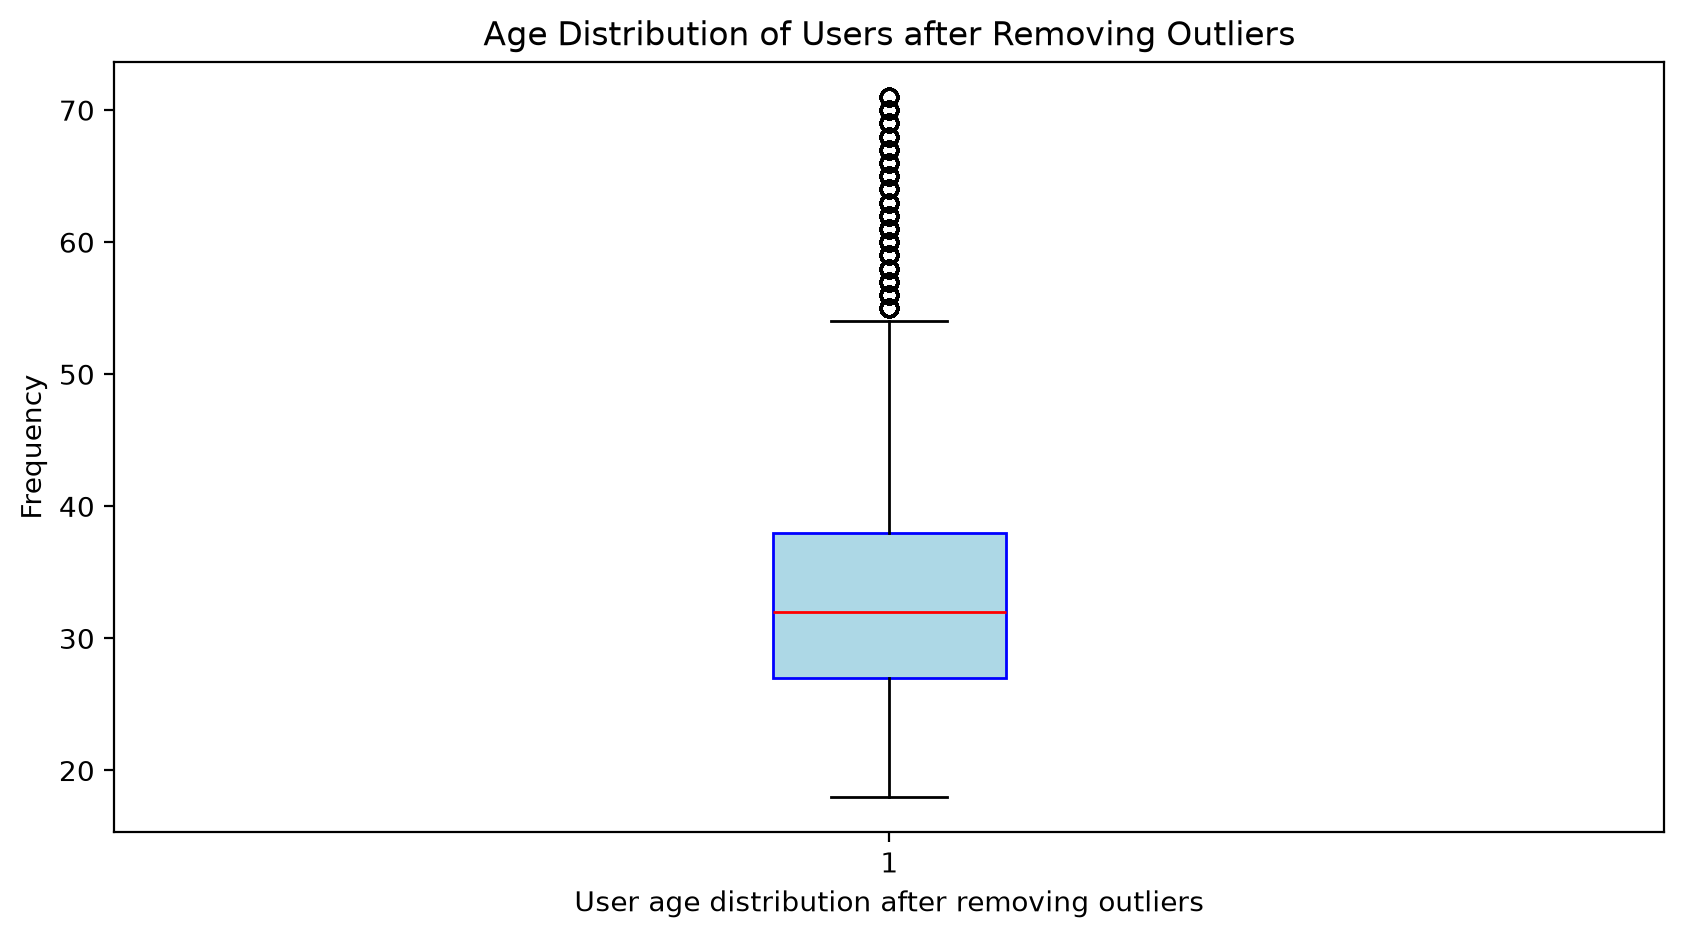

In [35]:
plt.figure(figsize = (10,5), dpi = 200)
plot = plt.boxplot(data['member_age'], patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'), medianprops=dict(color='red'))
plt.xlabel('User age distribution after removing outliers')
plt.ylabel('Frequency')
plt.title('Age Distribution of Users after Removing Outliers')
plt.show()

# <a id="5">  5 ) . What is the distribution for the trip duration in minutes? </a>

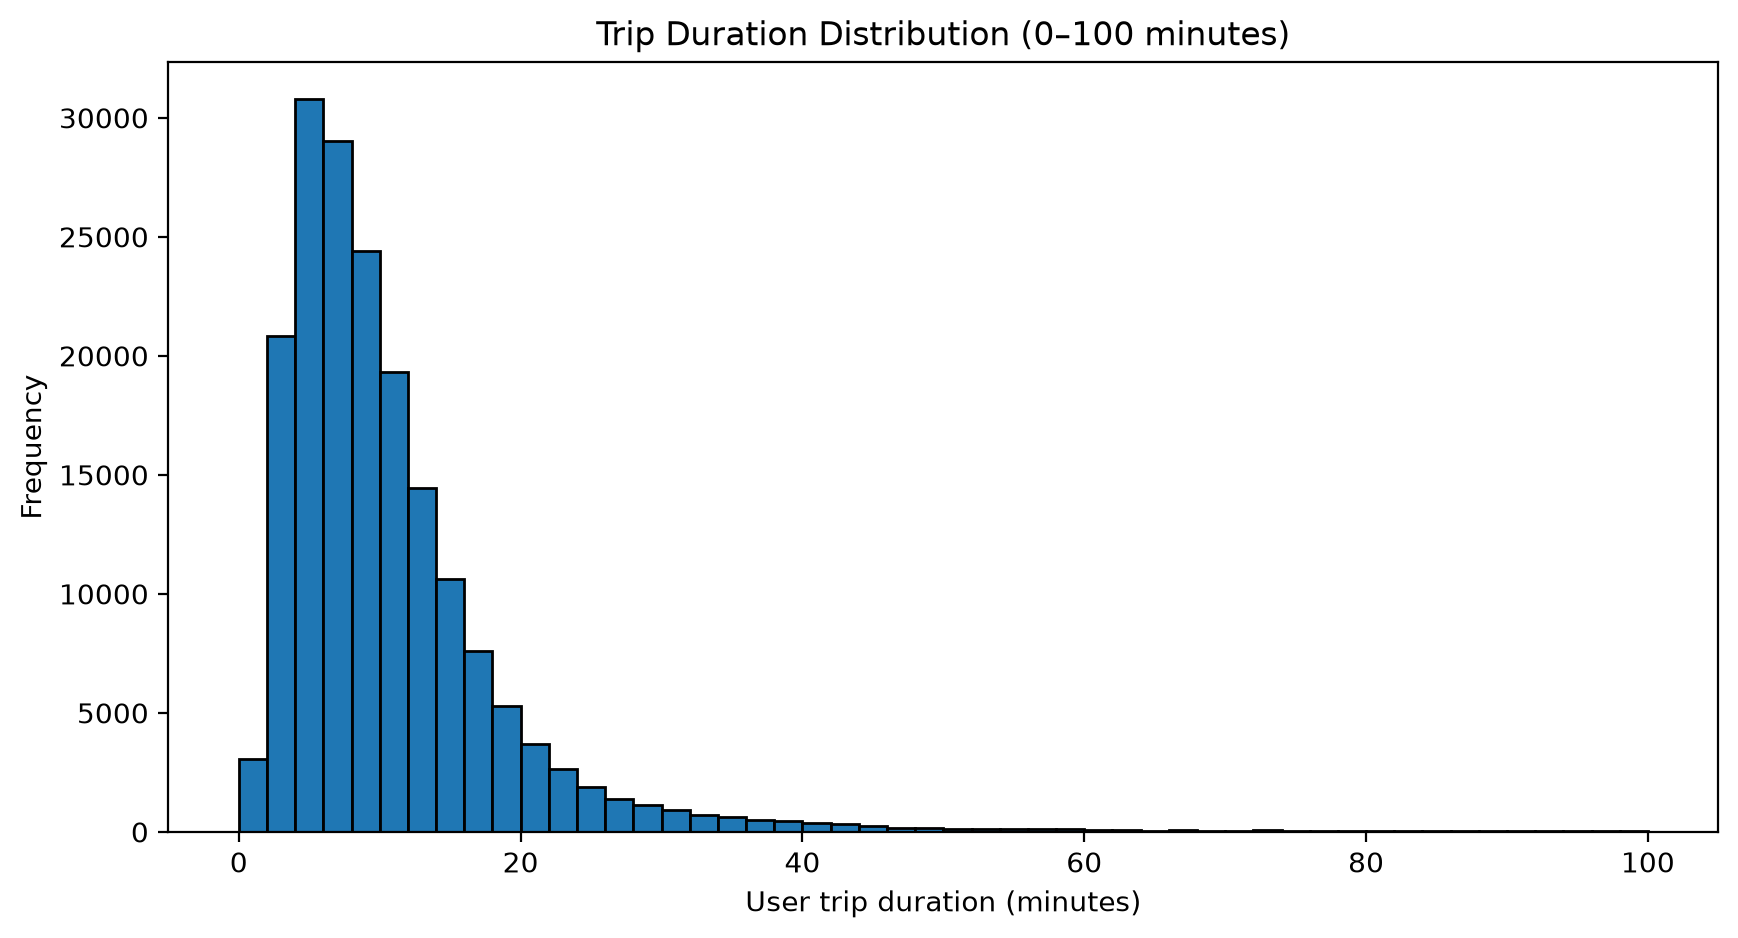

In [36]:
plt.figure(figsize=(10,5), dpi=200)

plt.hist(
    data['duration_min'],
    bins=50,
    range=(0, 100),
    edgecolor='black'
)

plt.xlabel('User trip duration (minutes)')
plt.ylabel('Frequency')
plt.title('Trip Duration Distribution (0–100 minutes)')
plt.show()

In [37]:
# Make visualization to easy get insight


> ### <mark>Your analsys and exploration here </mark>
The trip duration distribution is highly right-skewed, with most trips being relatively short and a small number of unusually long trips. Further investigation of extreme values is recommended.


# <a id="6"> 6 ) . What is the distribution for member_gender?</a>

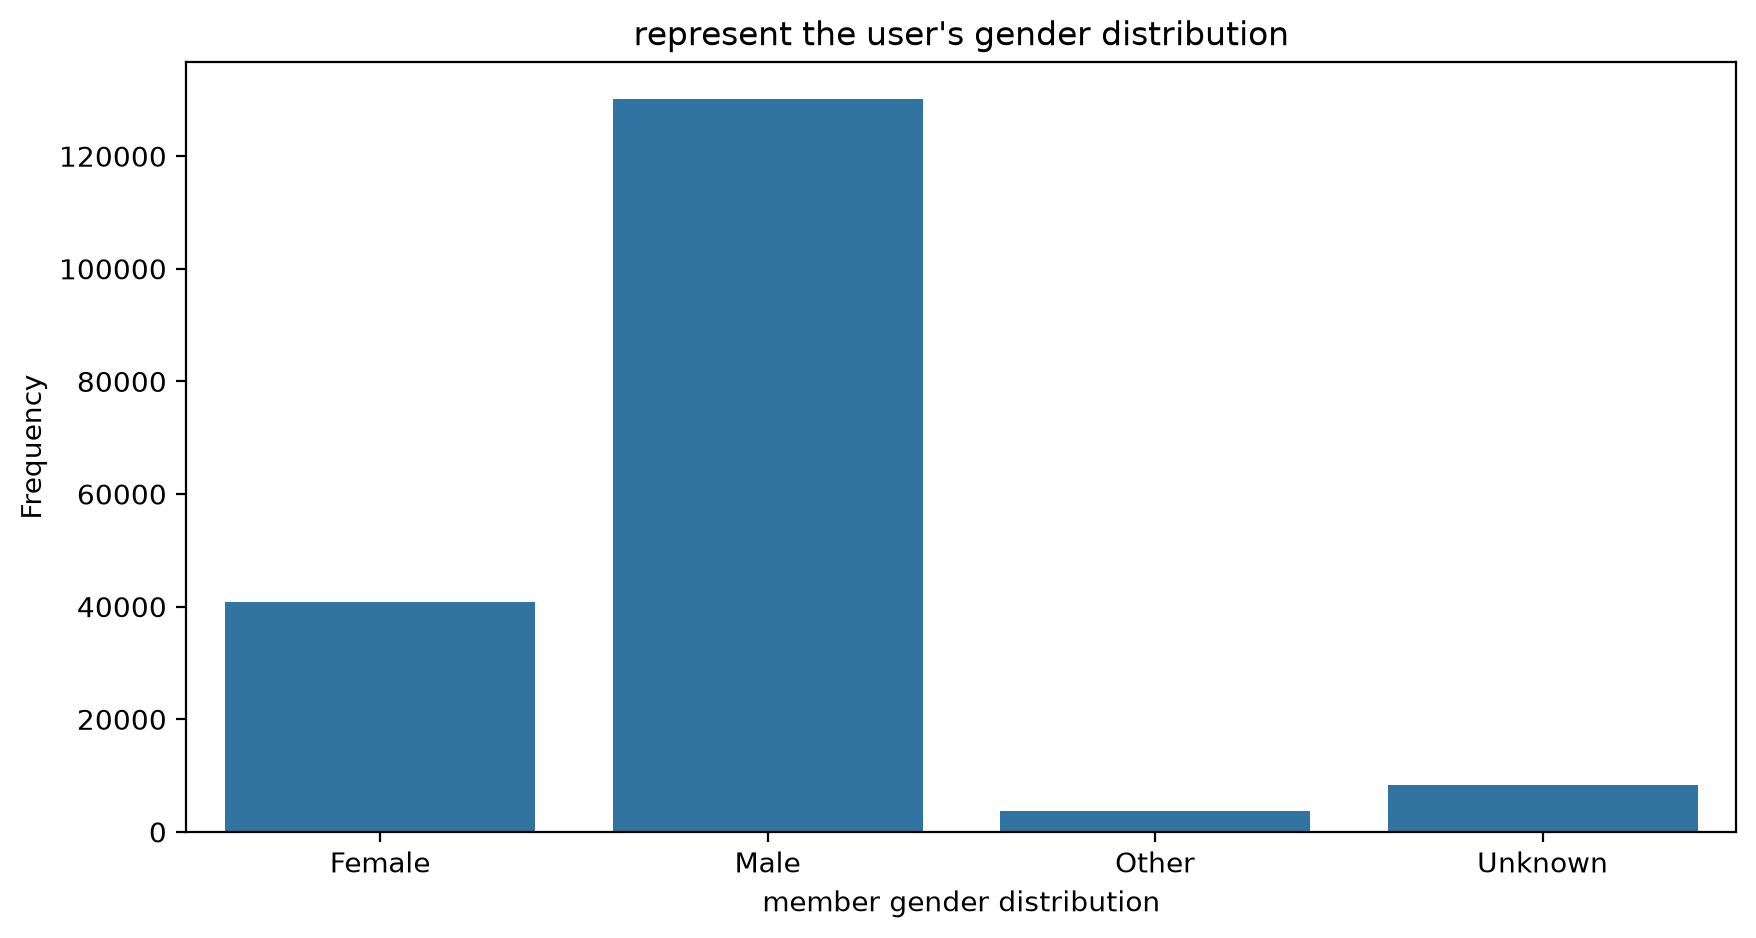

In [38]:

plt.figure(figsize = (10,5), dpi = 200)

plot = sns.countplot(data=data, x='member_gender')

plt.xlabel('member gender distribution')
plt.ylabel('Frequency')
plt.title("represent the user's gender distribution")

plt.show()

> ### <mark>Your analsys and exploration here </mark>

# <a id="7">    7 )  . What is the distribution for the trip duration in Hours?  </a>

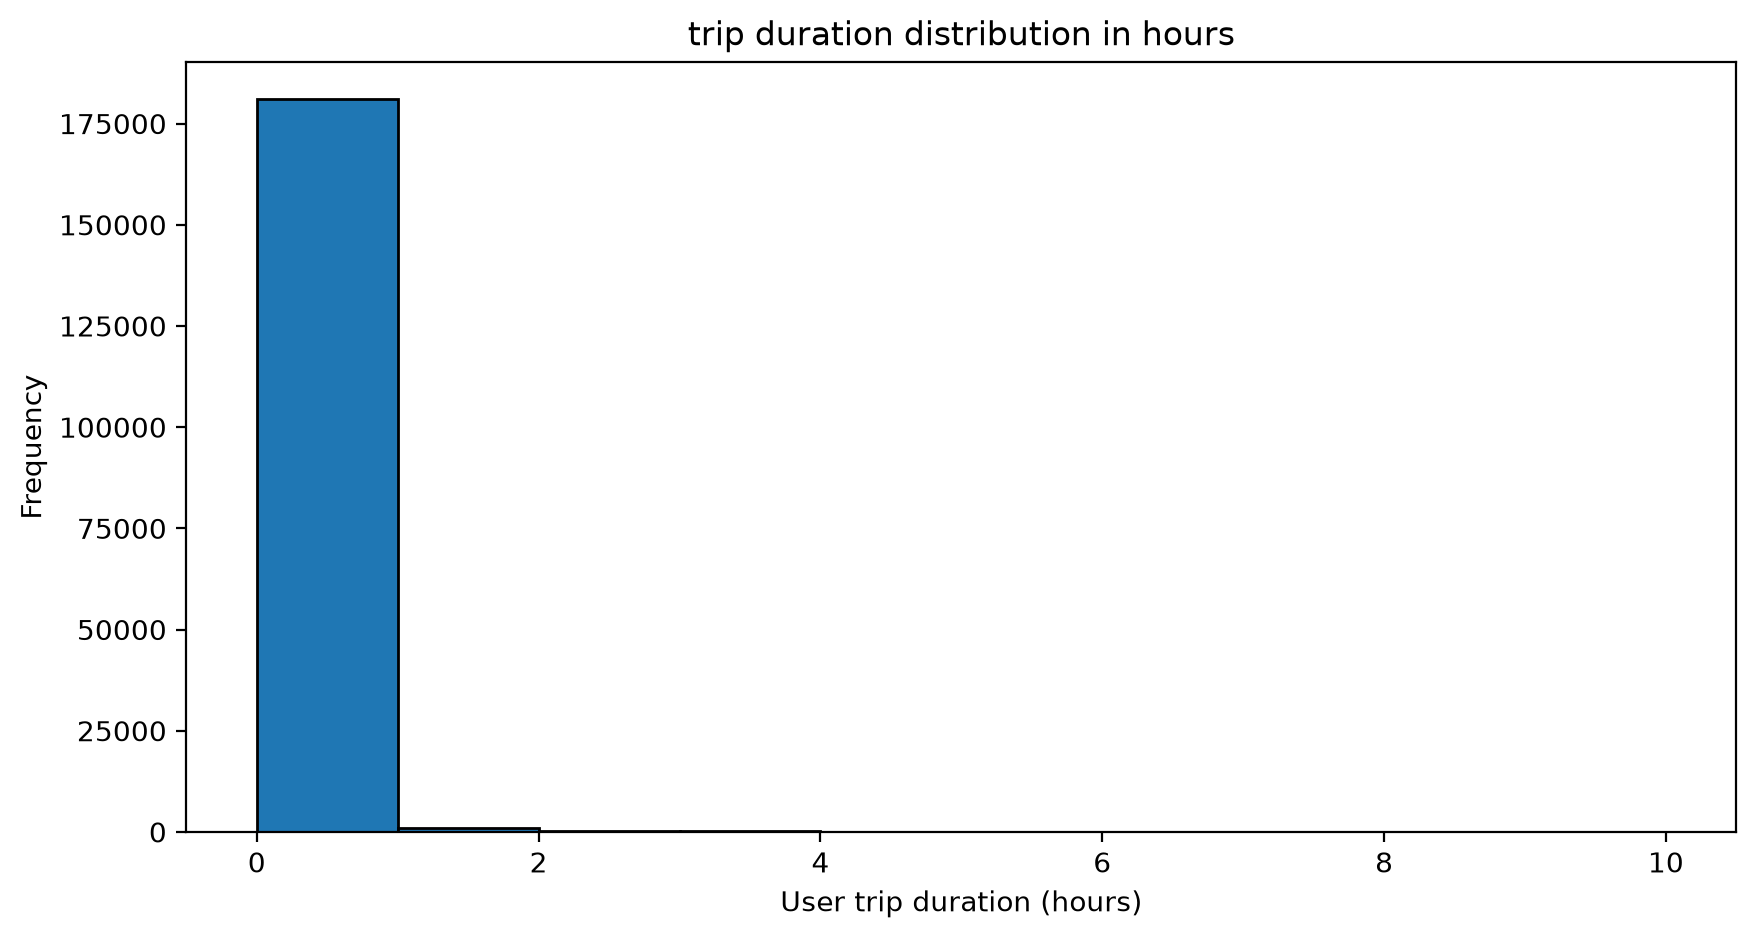

In [39]:
# Make visualization to easy get insight
plt.figure(figsize=(10,5), dpi=200)

plt.hist(
    data['duration_hour'],
    bins=10,
    range=(0, 10),
    edgecolor='black'
)

plt.xlabel('User trip duration (hours)')
plt.ylabel('Frequency')
plt.title("trip duration distribution in hours")

plt.show()

> ### <mark>Your analsys and exploration here </mark>


### The variables distribution:


> The distribution of duration present that most of the trips were less than 30 minutes ( we can notice that from the minutes and the hour charts )


> And the Age distribution is ( left Skewed ) as most users age are  22 - 39


> Most users are subscribers, not Customers and  Males as shown in the charts above.



### Were there any interesting and outliers 


- We got Age outliers for for more than 100 .



- The distribution of duration was strange where the minutes and the hour charts were 30 minutes or less.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Bivariate Exploration</p>
# <a id="111"> Bivariate Exploration</a>

Now let's investigate relationships between pairs of variables in our data.

# <a id="8"> 8) . What the average duration of trip for the categories of user type?</a>

                 mean  median   count
user_type                            
Customer    23.383980    13.0   19850
Subscriber  10.180314     8.0  163038


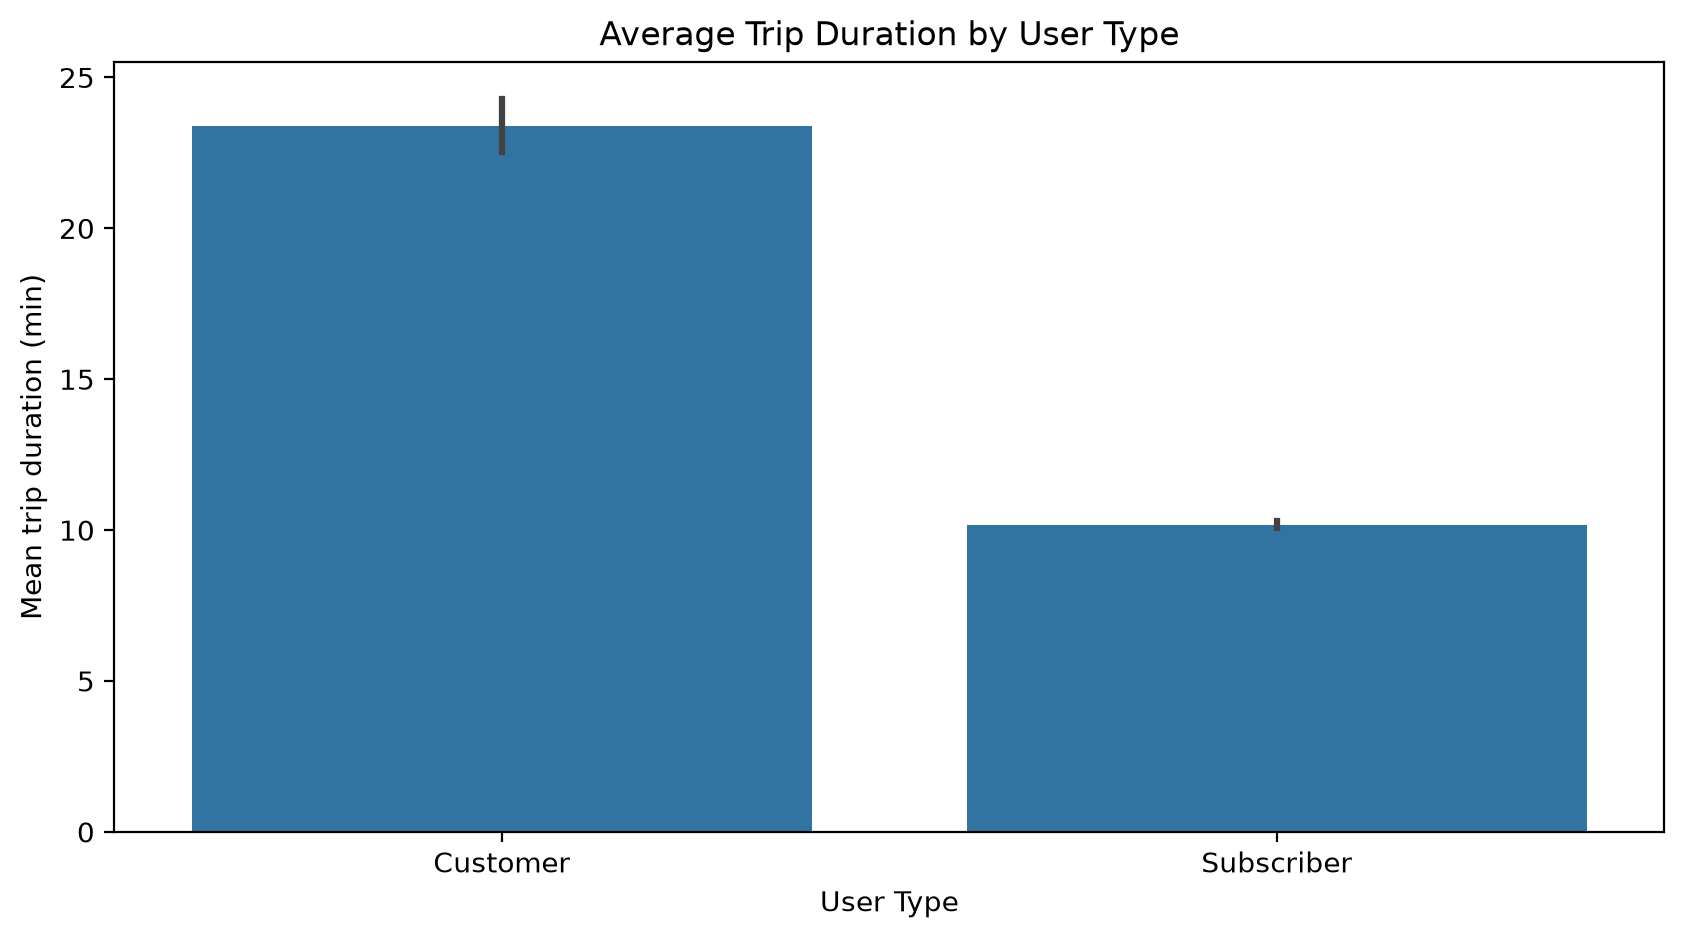

In [40]:
# Q8 — average duration per user type
avg = data.groupby('user_type', observed=True)['duration_min'].agg(['mean','median','count'])
print(avg)

plt.figure(figsize=(10,5), dpi=200)
sns.barplot(data=data, x='user_type', y='duration_min', estimator='mean',
            errorbar=('ci', 95))
plt.xlabel('User Type'); plt.ylabel('Mean trip duration (min)')
plt.title('Average Trip Duration by User Type')
plt.show()

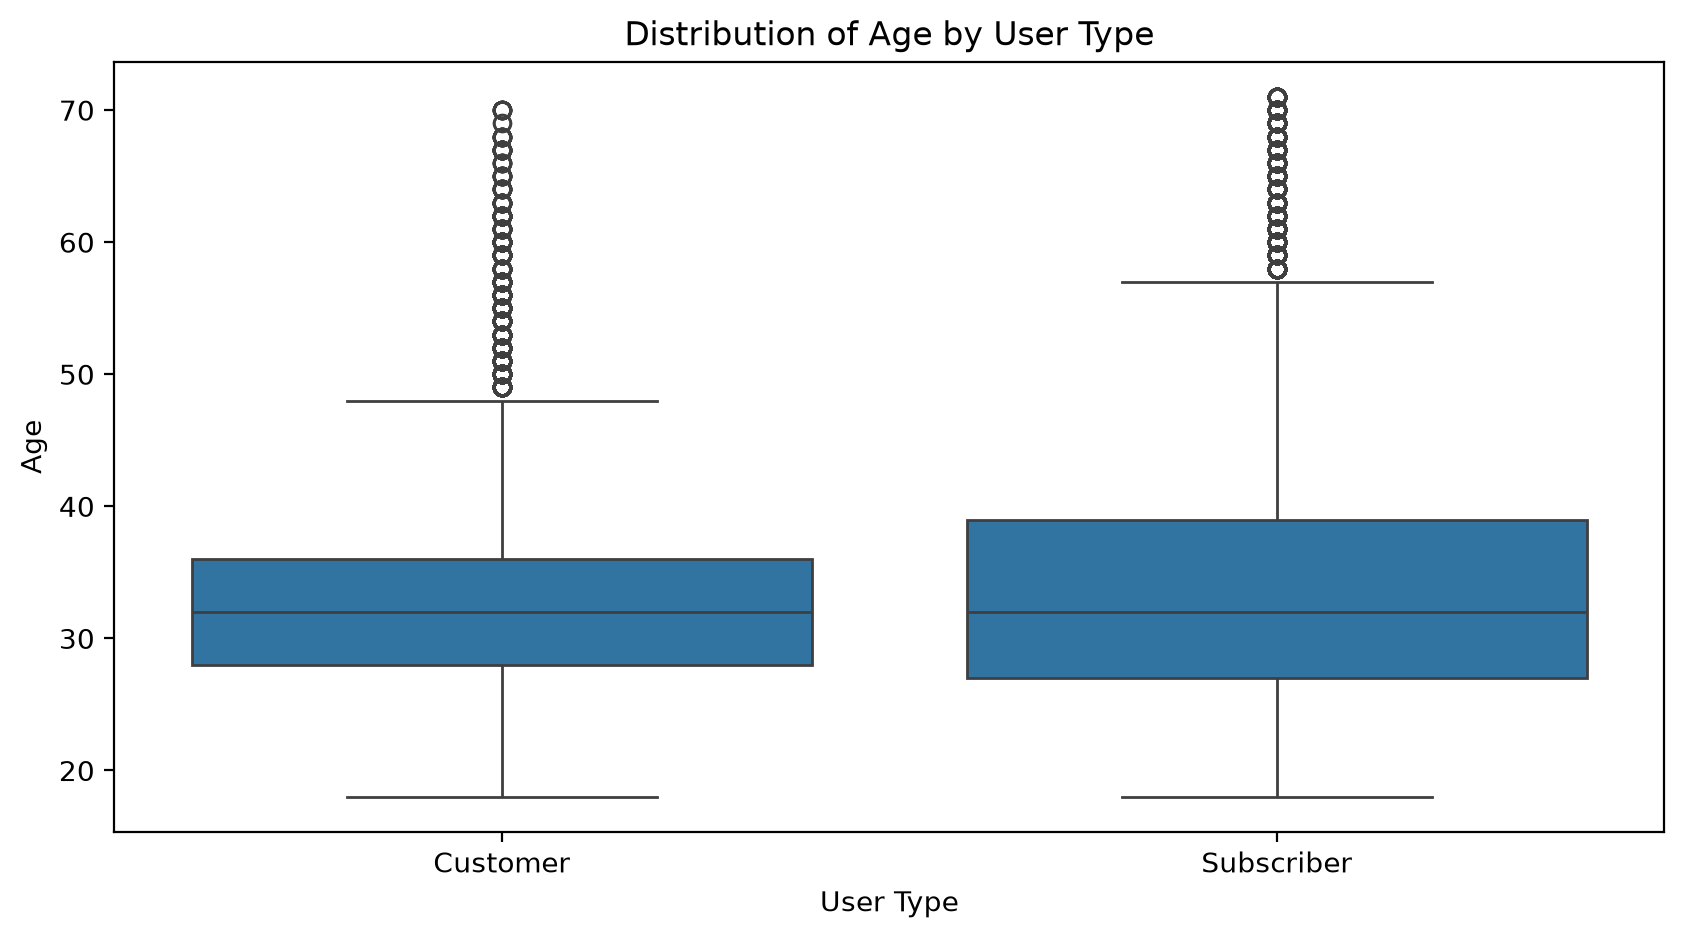

In [41]:
# Distribution of Age by user types
plt.figure(figsize=(10,5), dpi=200)
sns.boxplot(data=data, x='user_type', y='member_age')
plt.xlabel('User Type')
plt.ylabel('Age')
plt.title('Distribution of Age by User Type')
plt.show()


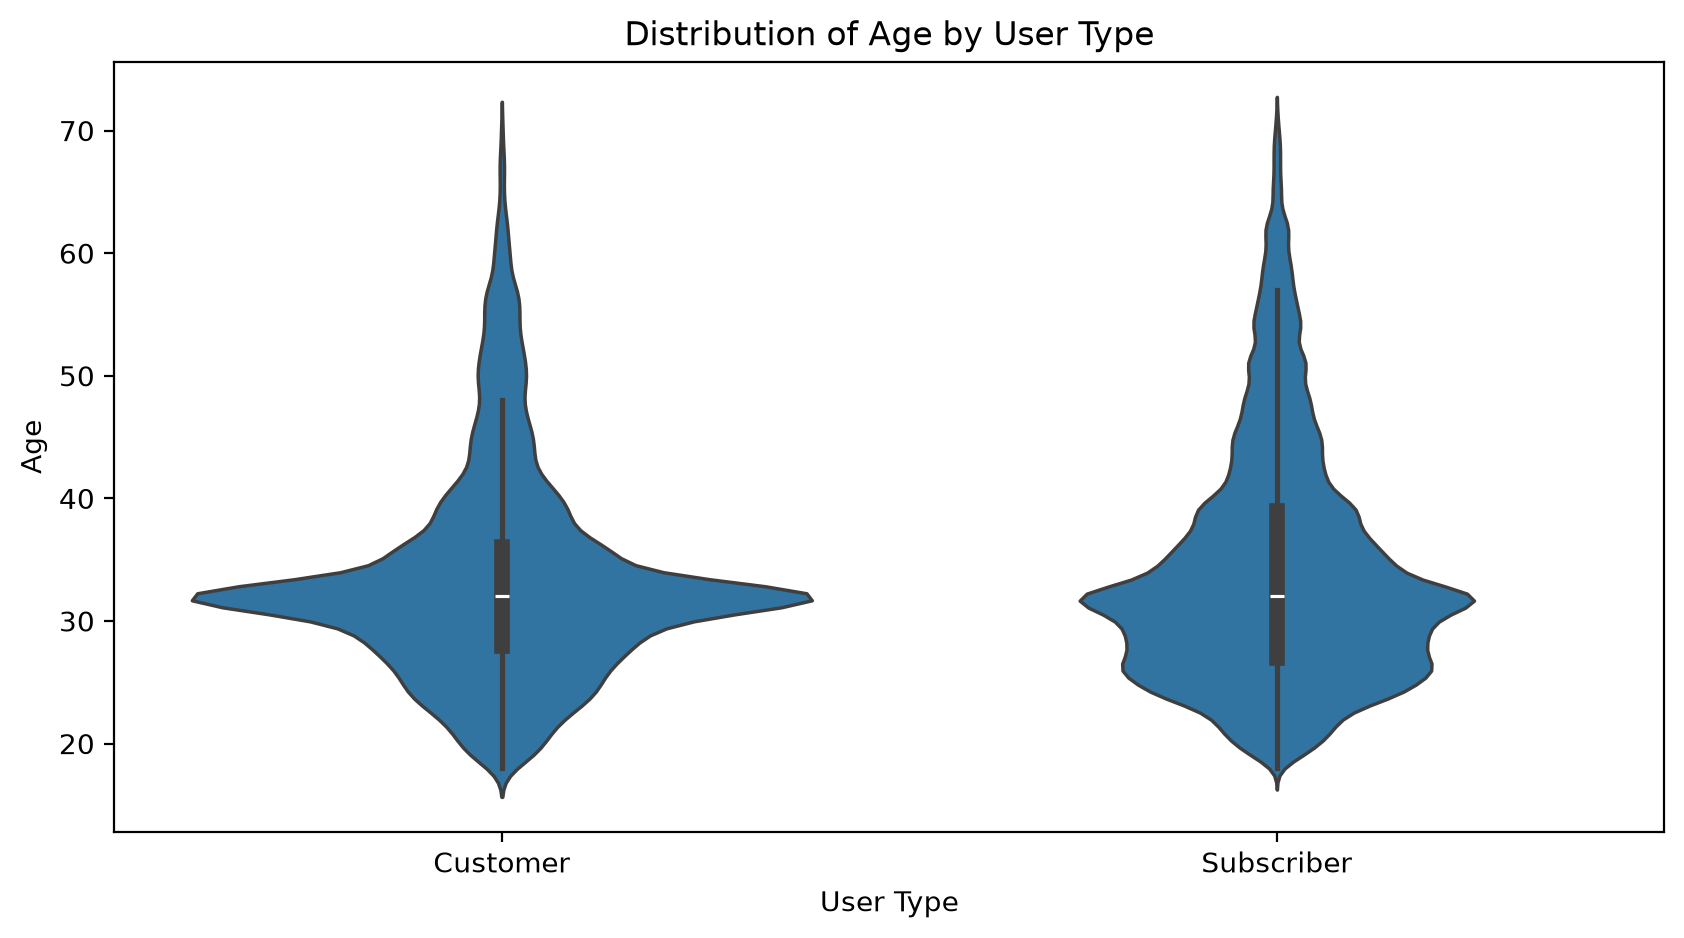

In [42]:
# Distribution of Age by user types
plt.figure(figsize=(10,5), dpi=200)
sns.violinplot(data=data, x='user_type', y='member_age')
plt.xlabel('User Type')
plt.ylabel('Age')
plt.title('Distribution of Age by User Type')
plt.show()


# Make visualization to easy get insight


> ### <mark>Your analsys and exploration here </mark>

# <a id="9">    9 ) . How long is the duration of the trip for each gender in minutes?  </a>

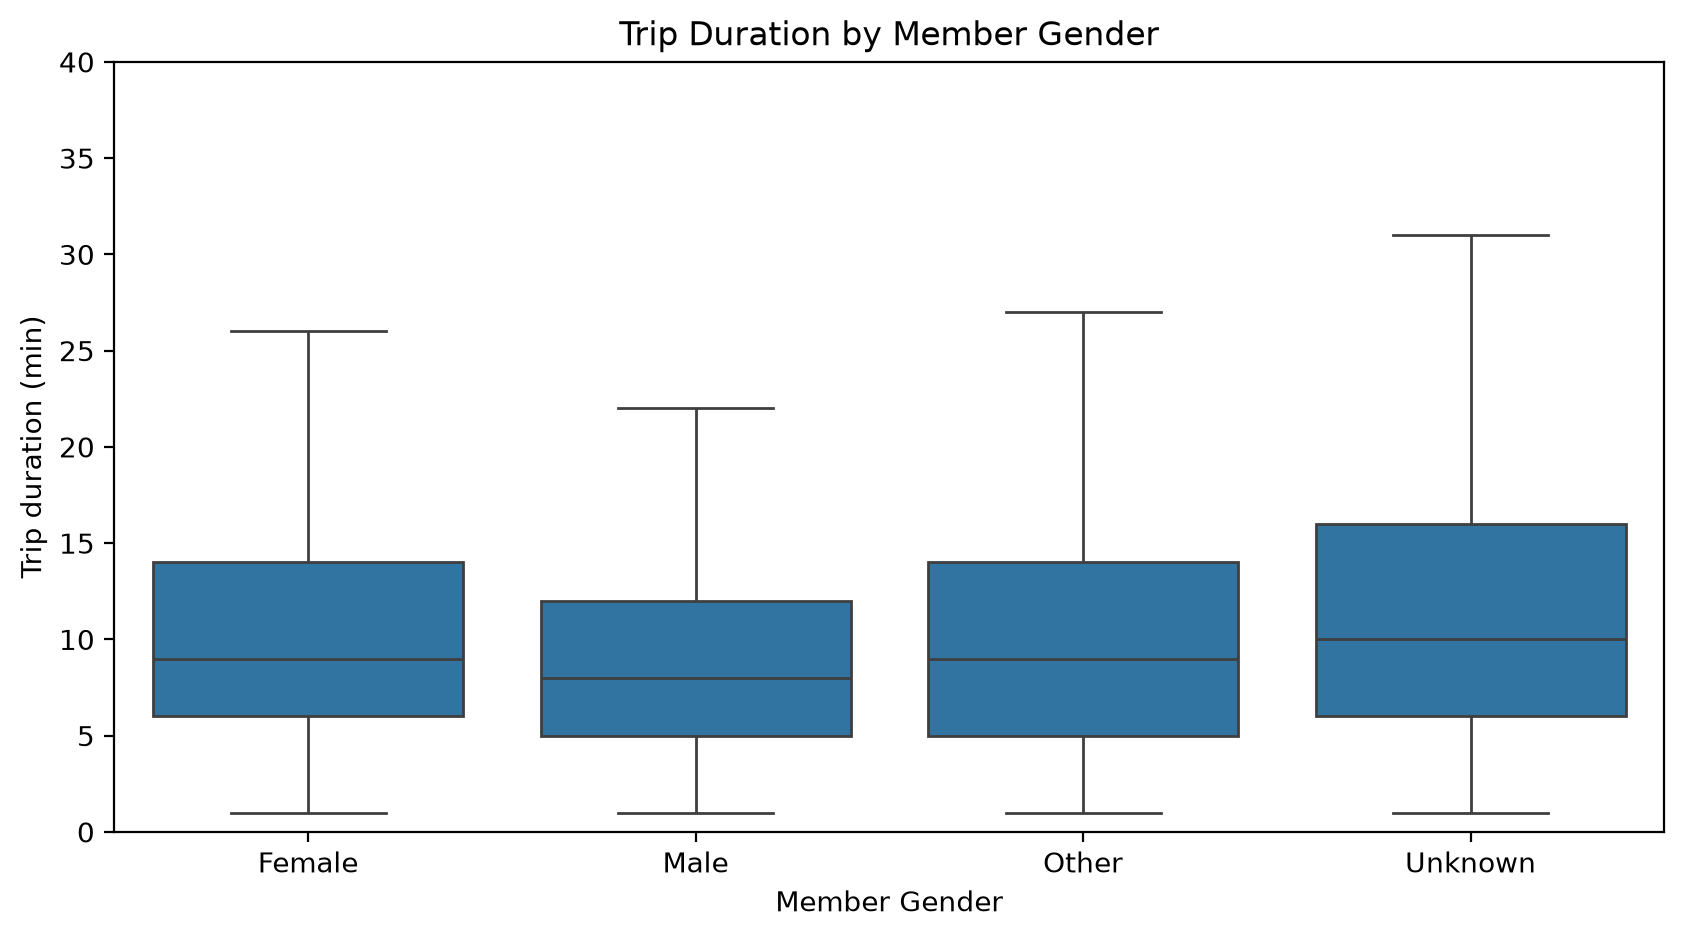

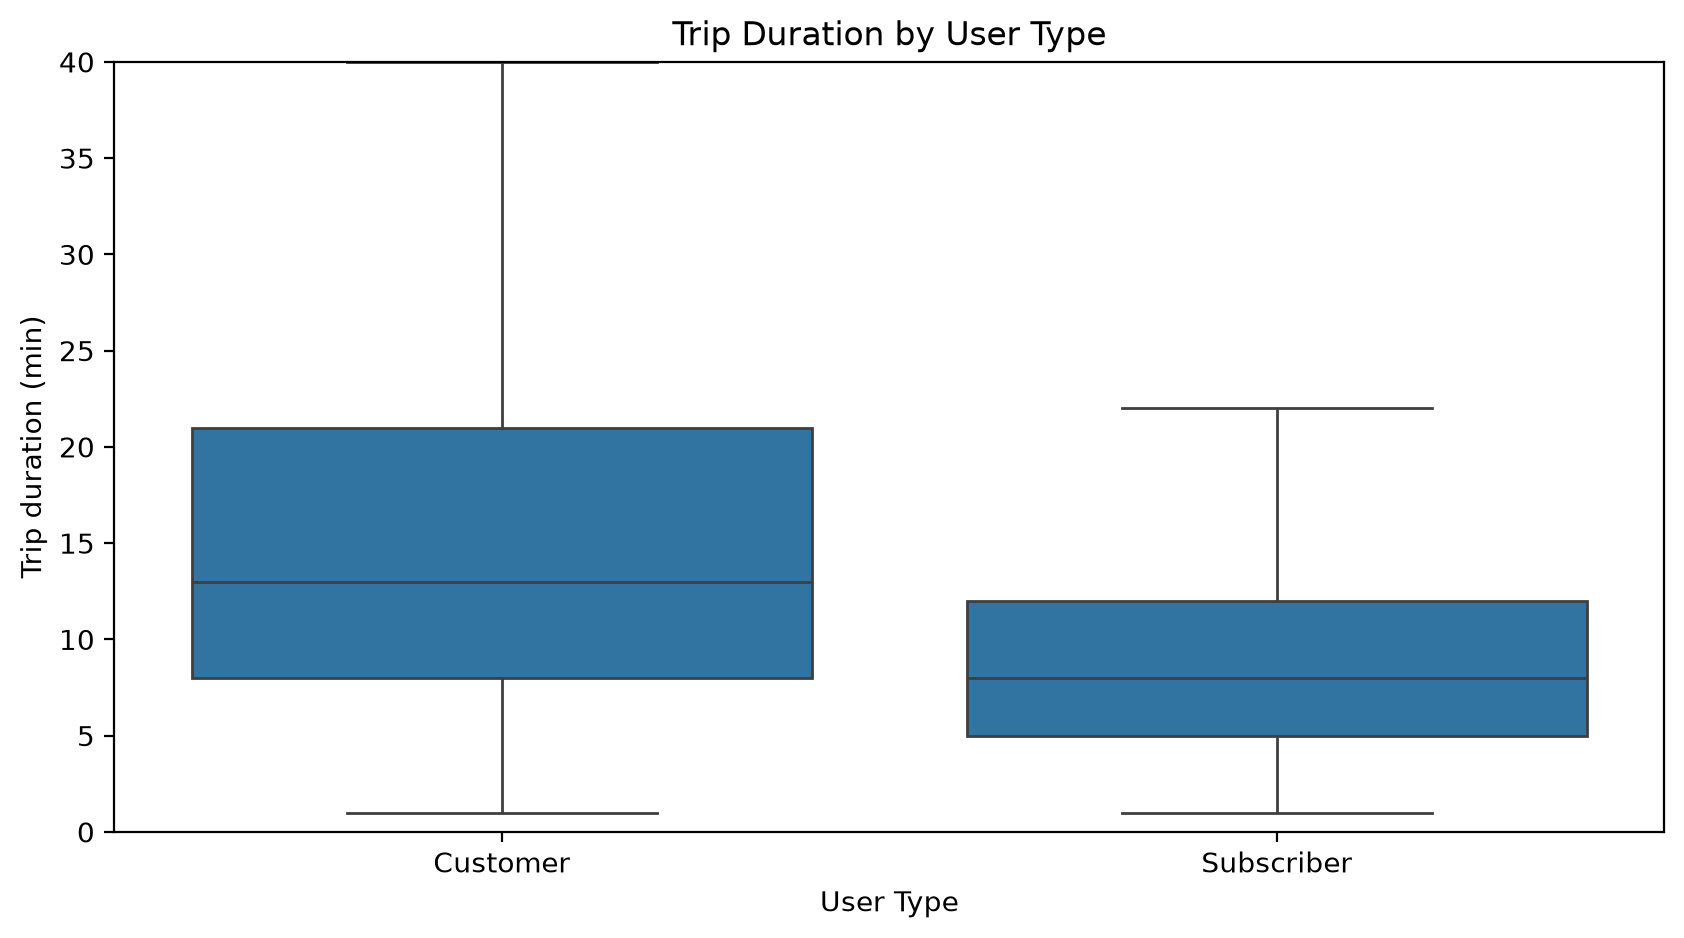

In [43]:
# Q9 — duration per gender, Q10 — duration per user type (distribution, not just mean)
for col, label in [('member_gender','Member Gender'), ('user_type','User Type')]:
    plt.figure(figsize=(10,5), dpi=200)
    sns.boxplot(data=data, x=col, y='duration_min', showfliers=False)
    plt.ylim(0, 40)                     # the tail is extreme; clip for readability
    plt.xlabel(label); plt.ylabel('Trip duration (min)')
    plt.title(f'Trip Duration by {label}')
    plt.show()

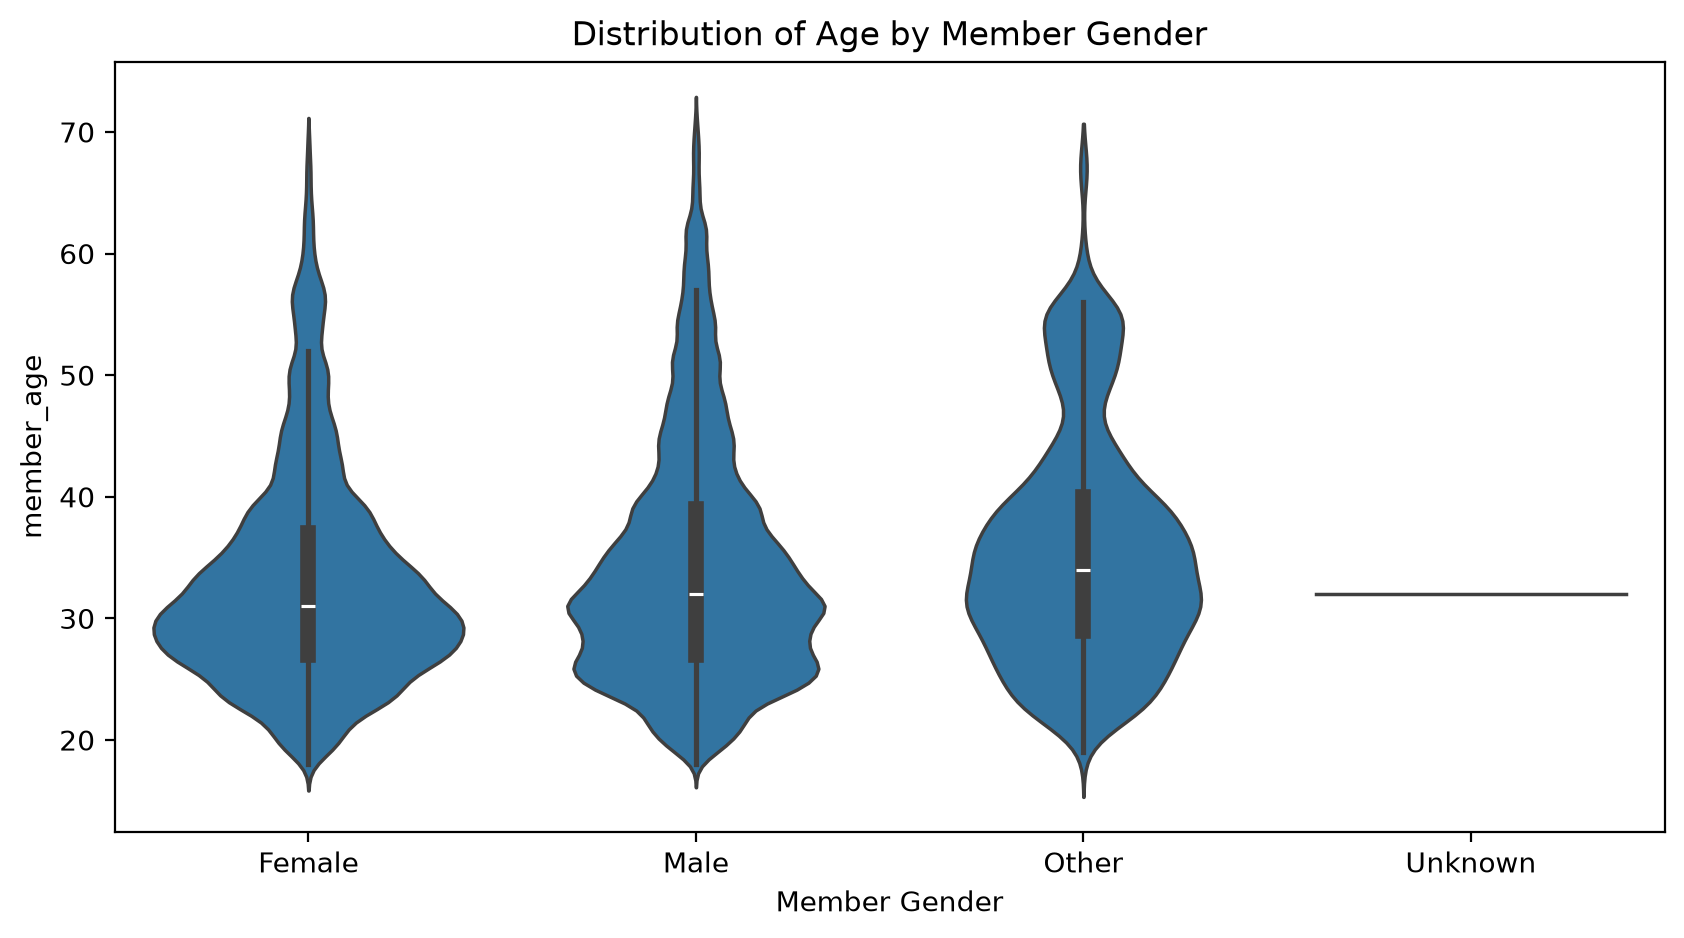

In [44]:
# Make visualization to easy get insight

# ------------------------Duration distribution by member gender
# Distribution of Age by user types
plt.figure(figsize=(10,5), dpi=200)
sns.violinplot(data=data, x='member_gender', y='member_age')
plt.xlabel('Member Gender')
plt.ylabel('member_age')
plt.title('Distribution of Age by Member Gender')
plt.show()




# Make visualization to easy get insight


> ### <mark>Your analsys and exploration here </mark>

# <a id="10 "> 10 ) . How long is the duration of the trip for each user_type in minutes?  </a>

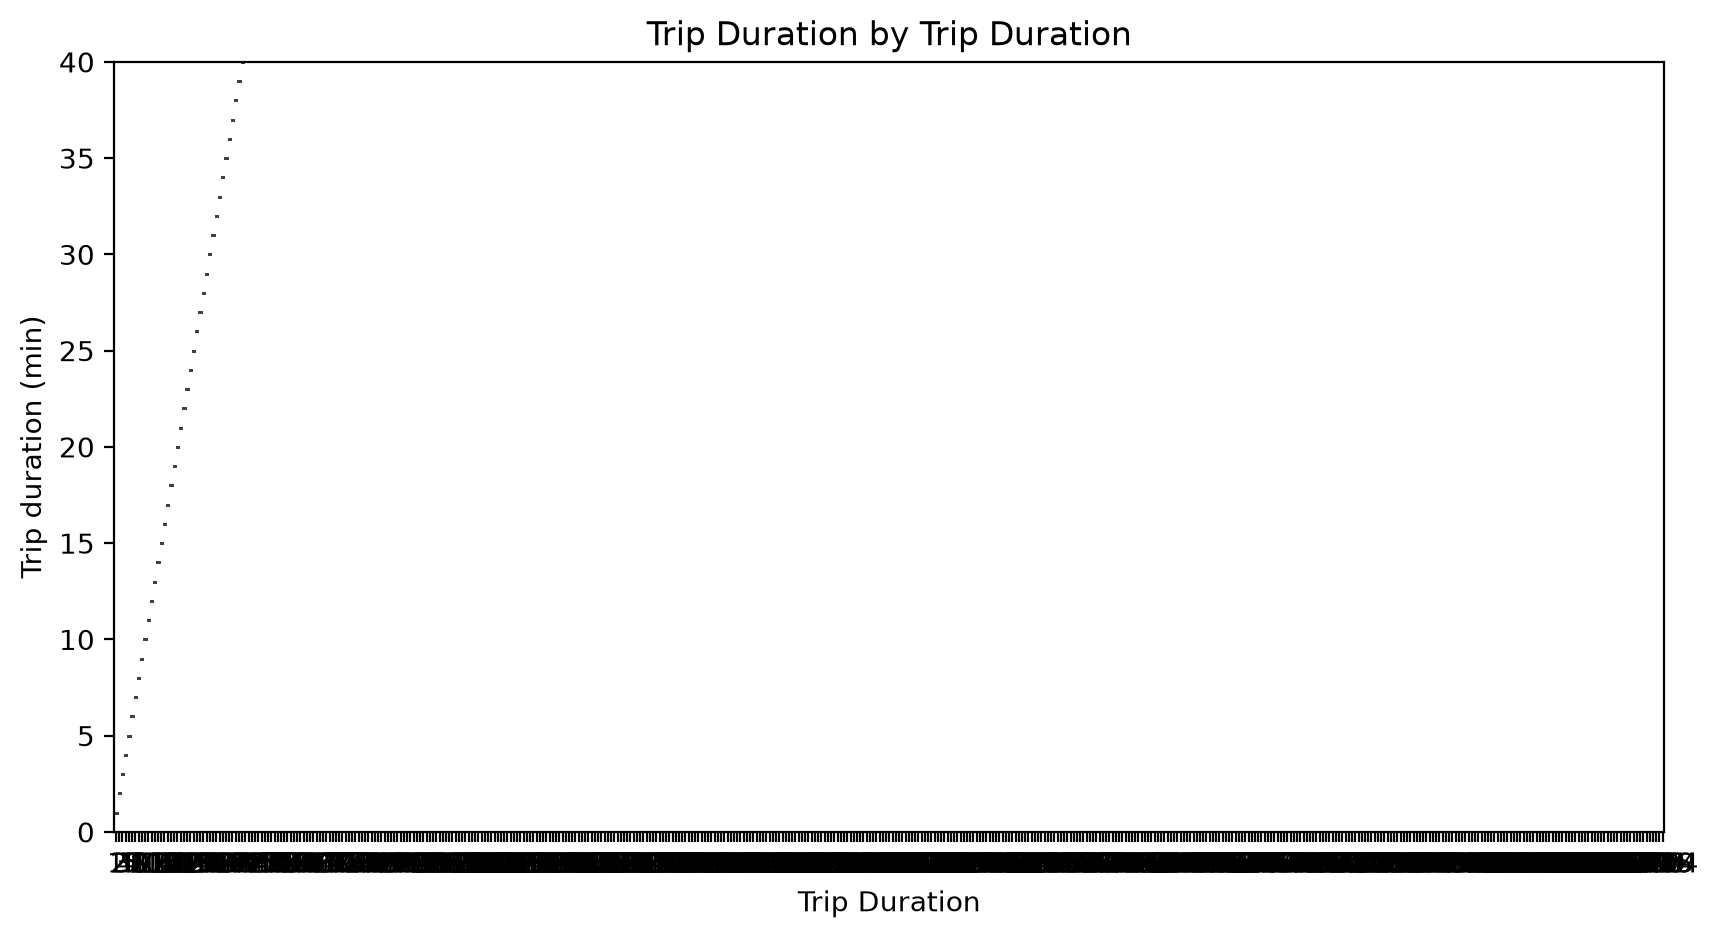

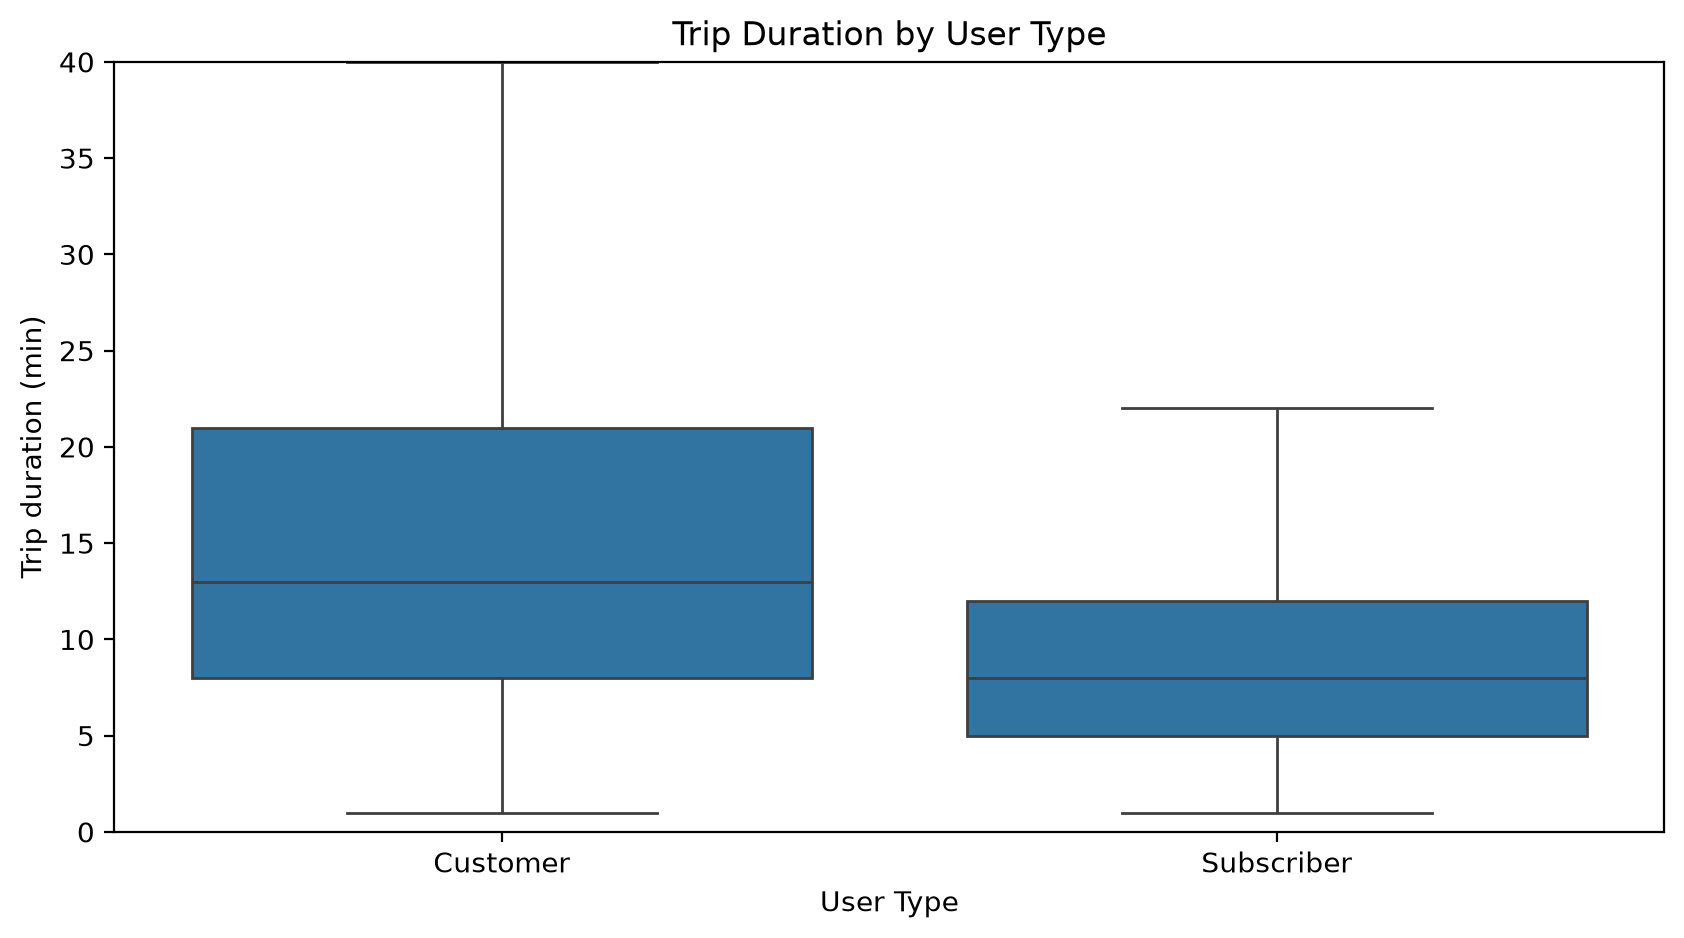

In [45]:
# Q9 — duration per gender, Q10 — duration per user type (distribution, not just mean)
for col, label in [('duration_min','Trip Duration'), ('user_type','User Type')]:
    plt.figure(figsize=(10,5), dpi=200)
    sns.boxplot(data=data, x=col, y='duration_min', showfliers=False)
    plt.ylim(0, 40)                     # the tail is extreme; clip for readability
    plt.xlabel(label); plt.ylabel('Trip duration (min)')
    plt.title(f'Trip Duration by {label}')
    plt.show()

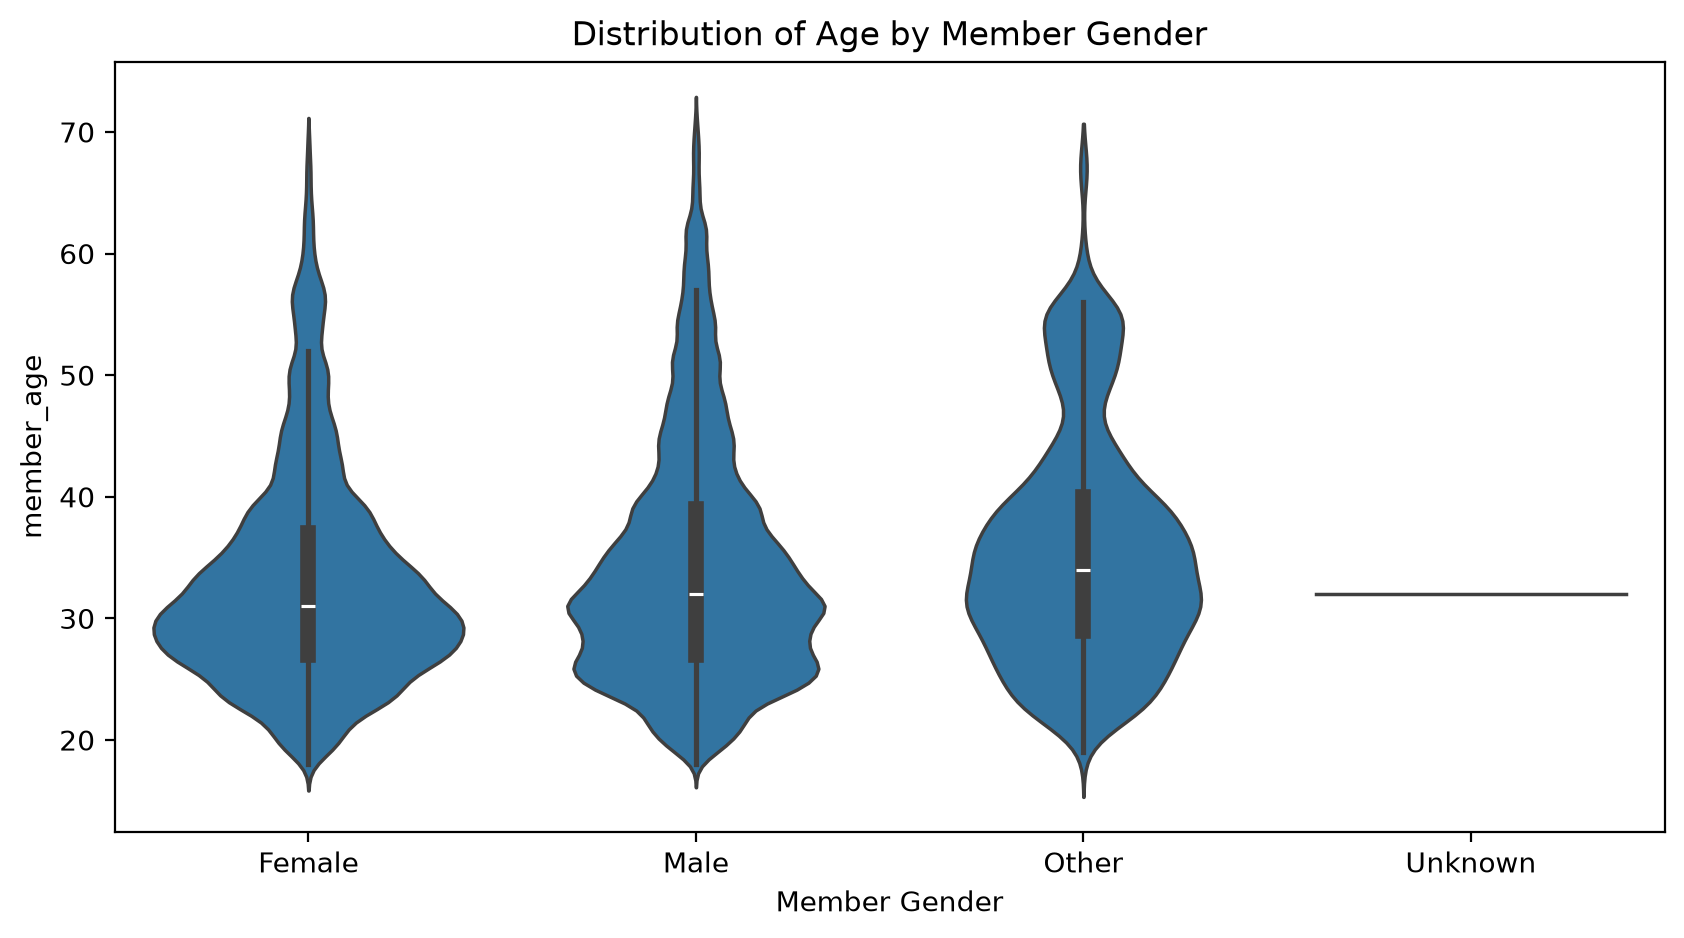

In [46]:

# Make visualization to easy get insight
plt.figure(figsize=(10,5), dpi=200)
sns.violinplot(data=data, x='member_gender', y='member_age')
plt.xlabel('Member Gender')
plt.ylabel('member_age')
plt.title('Distribution of Age by Member Gender')
plt.show()


> ### <mark>Your analsys and exploration here </mark>

# <a id="11">  11 ) . How the user distribution depending on their Age and user_type ? </a>

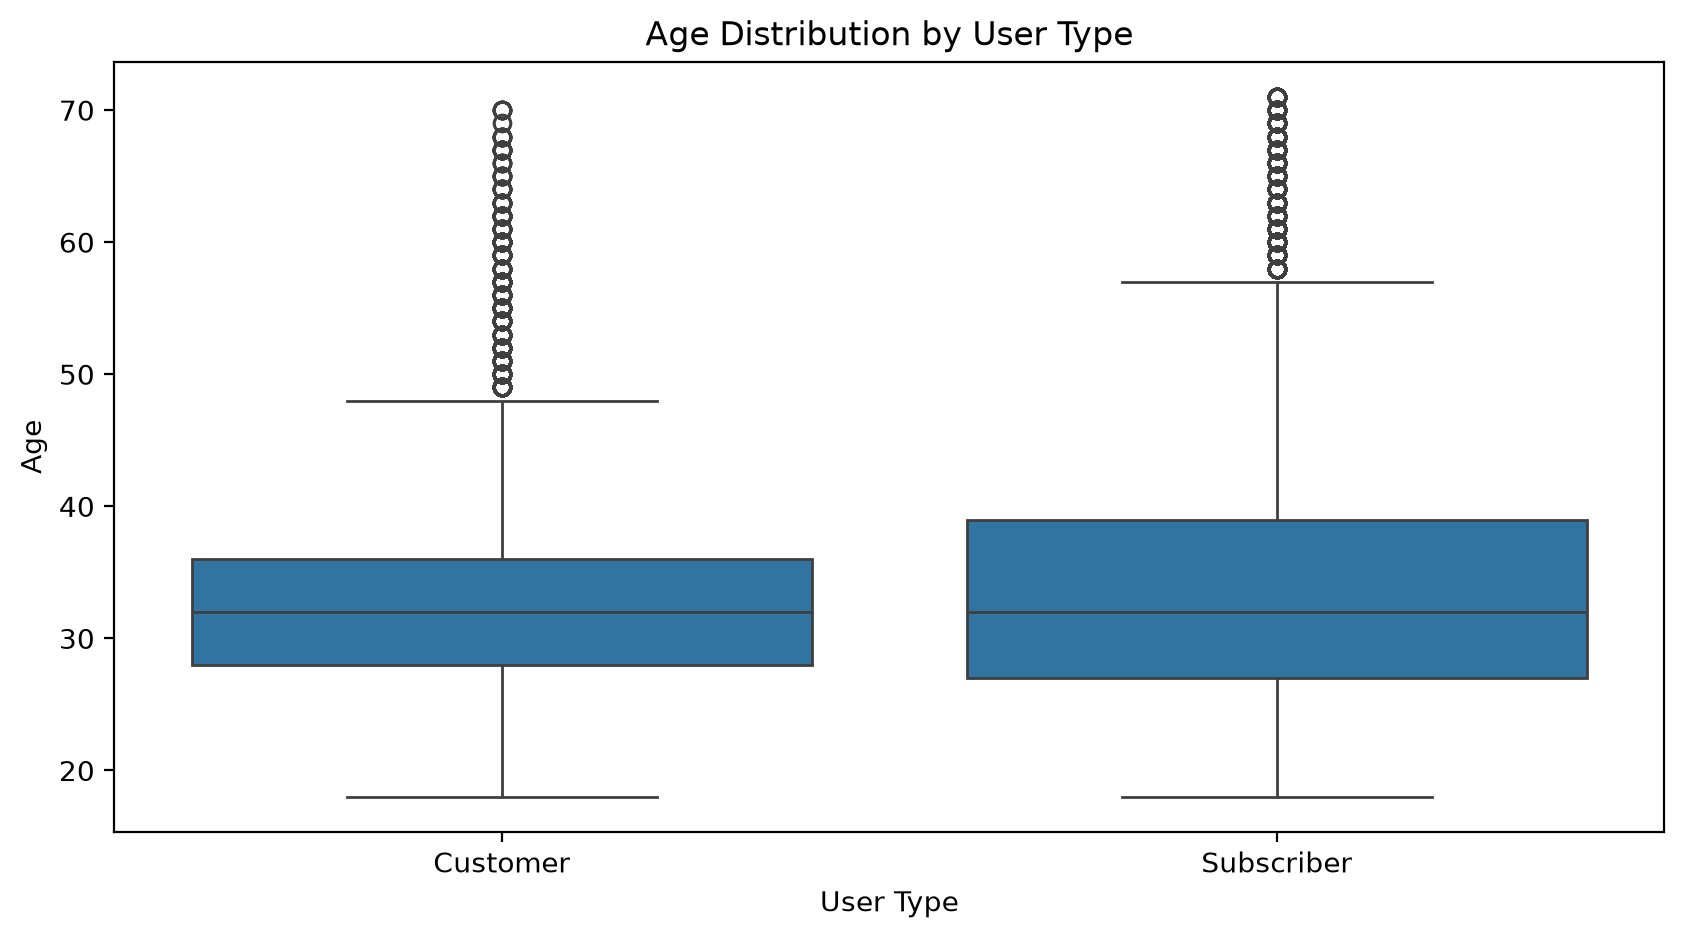

In [47]:

# Make visualization to easy get insight
plt.figure(figsize=(10, 5), dpi=200)
sns.boxplot(data=data, x='user_type', y='member_age')

plt.xlabel('User Type')
plt.ylabel('Age')
plt.title('Age Distribution by User Type')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_28228\99931150.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='user_type', y='member_age', inner='quartile', palette='pastel')


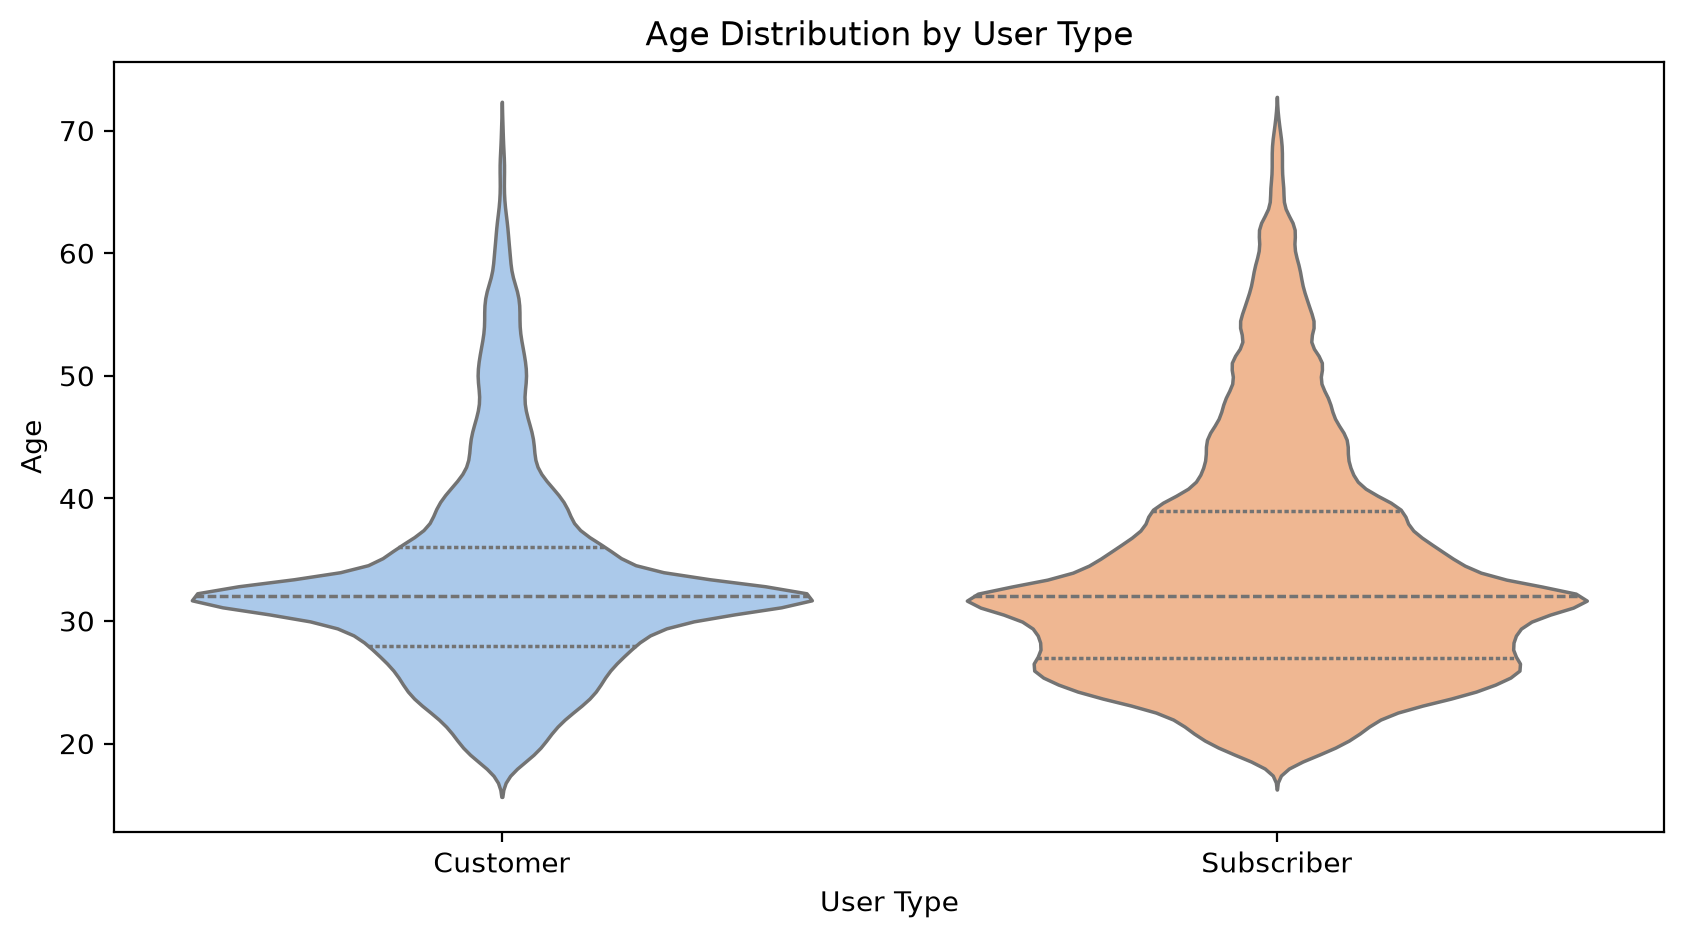

In [48]:
plt.figure(figsize=(10, 5), dpi=200)

sns.violinplot(data=data, x='user_type', y='member_age', inner='quartile', palette='pastel')

plt.xlabel('User Type')
plt.ylabel('Age')
plt.title('Age Distribution by User Type')
plt.show()

> ### <mark>Your analsys and exploration here </mark>

#  <a id="12"> 12 ). How the user distribution depending on their Age and member_gender ?</a>

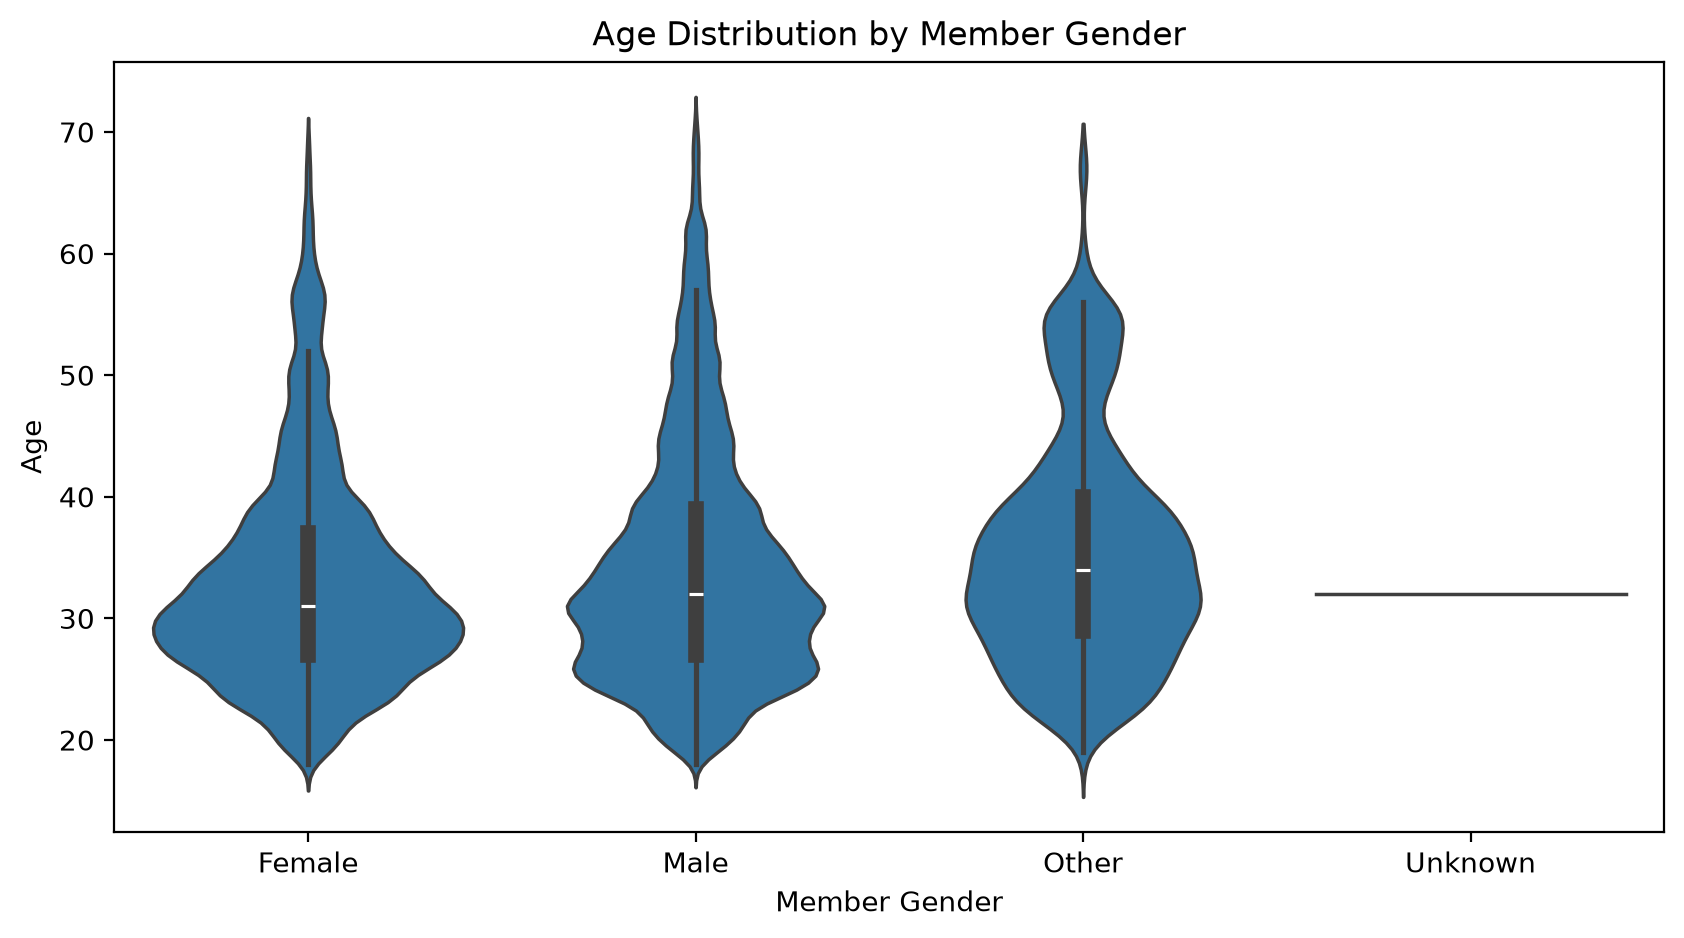

In [49]:
# Make visualization to easy get insight
plt.figure(figsize=(10, 5), dpi=200)

sns.violinplot(data=data, x='member_gender', y='member_age')

plt.xlabel('Member Gender')
plt.ylabel('Age')
plt.title('Age Distribution by Member Gender')
plt.show()

> ### <mark>Your analsys and exploration here </mark>

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> ...................


### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> ....................

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Multivariate Exploration</p>
# <a id="1111"> Multivariate Exploration </a>

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

In [50]:
## check your work 



# <a id="13">  13 ) . What is the  Correlation between each variable in the dataset?</a>

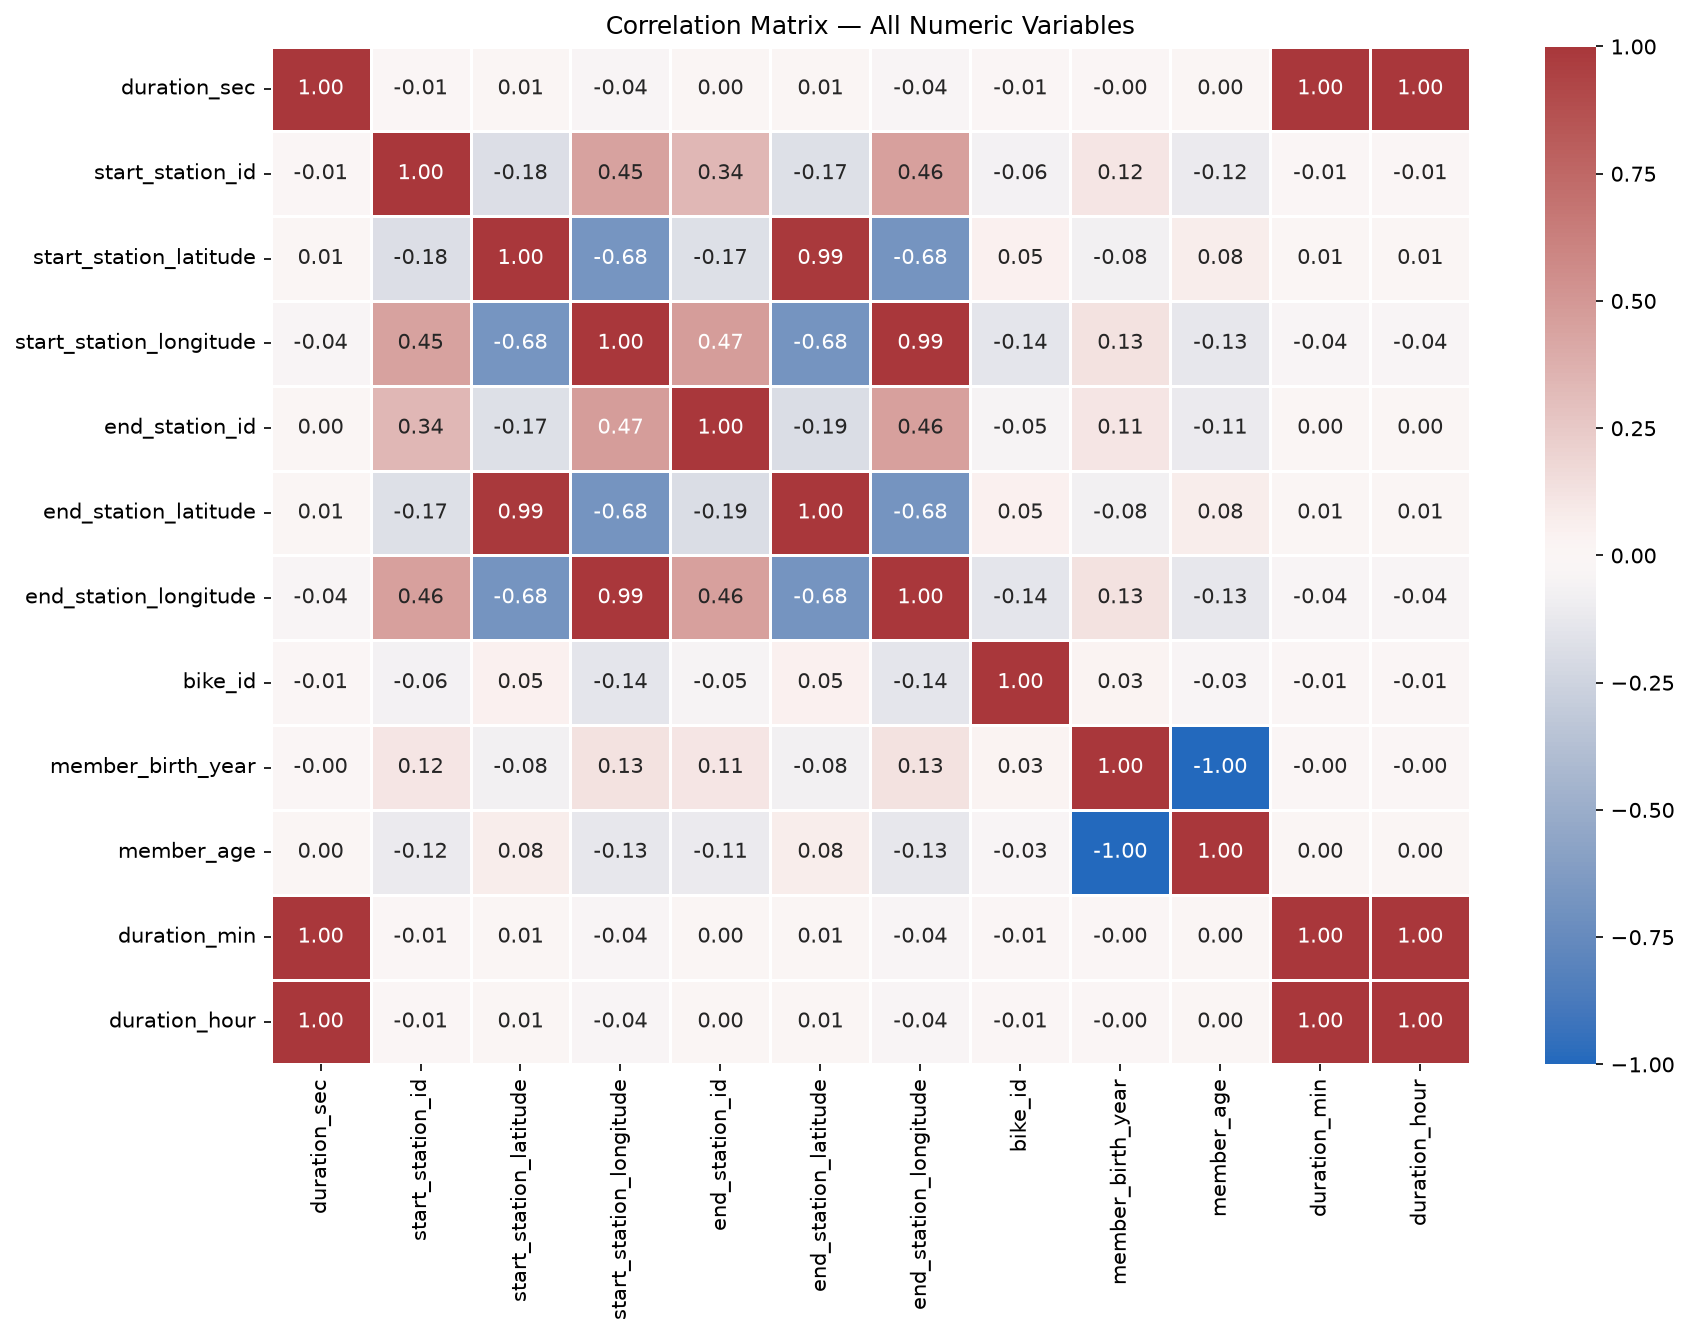

In [51]:
# Make visualization to easy get insight
corr_all = data.corr(numeric_only=True)

plt.figure(figsize=(12,9), dpi=150)
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='vlag', center=0,
            vmin=-1, vmax=1, linewidths=.5)
plt.title('Correlation Matrix — All Numeric Variables')
plt.tight_layout(); plt.show()



> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes/hours`)



# <a id="14"> 14 )  .  What is the  Correlation between `specific numeric variables` in the dataset?</a>


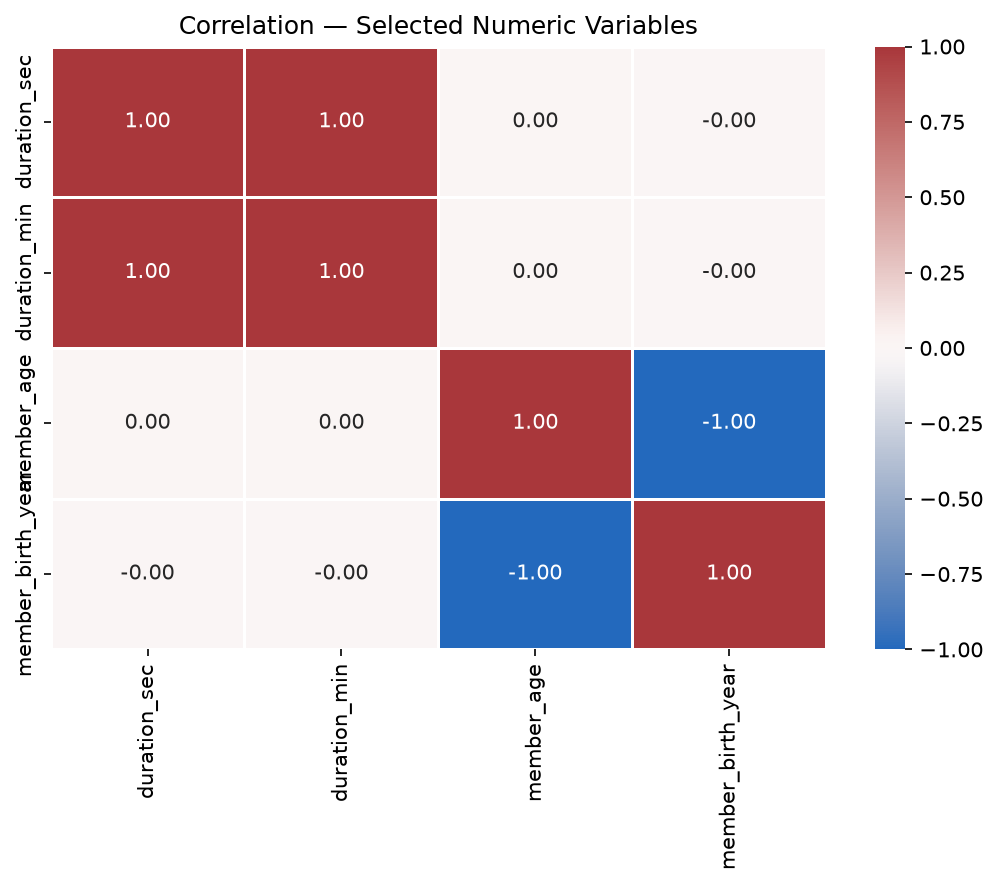

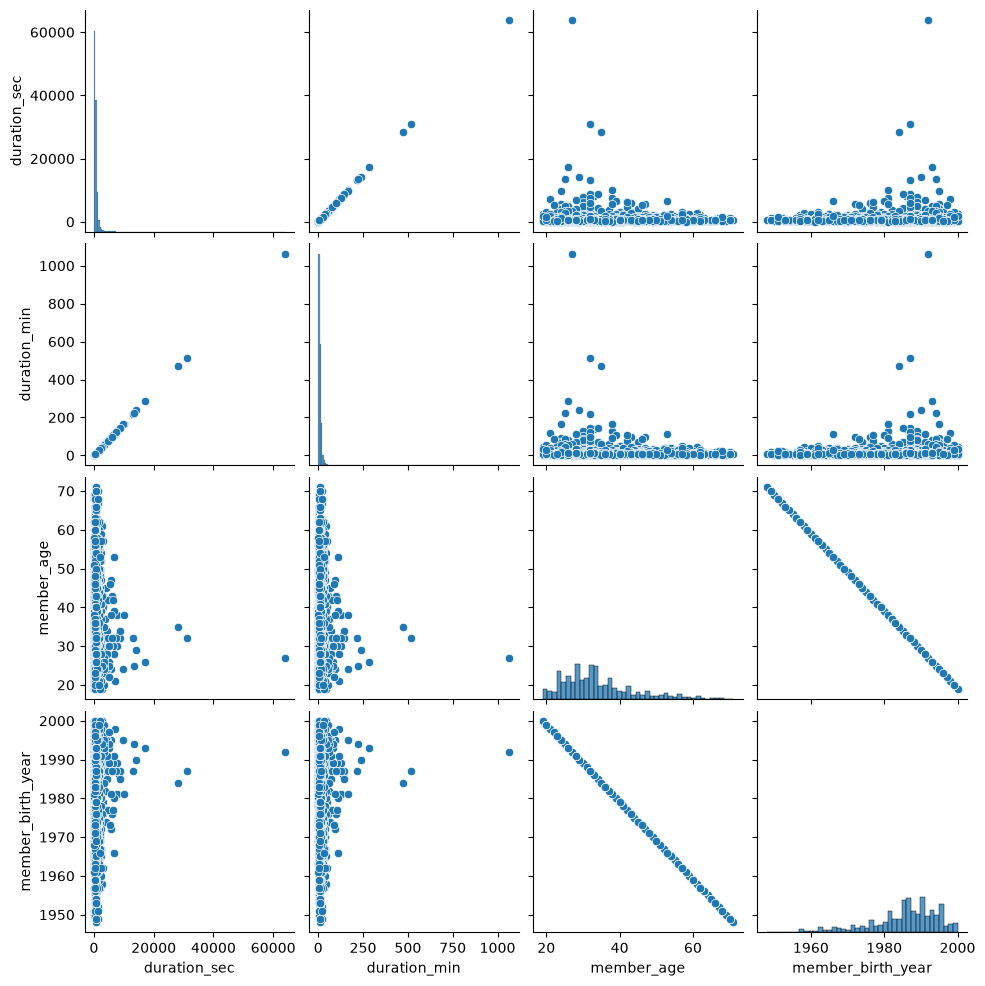

In [52]:
# Make visualization to easy get insight

subset = ['duration_sec', 'duration_min', 'member_age', 'member_birth_year']
plt.figure(figsize=(7,6), dpi=150)
sns.heatmap(data[subset].corr(), annot=True, fmt='.2f', cmap='vlag',
            center=0, vmin=-1, vmax=1, linewidths=.5)
plt.title('Correlation — Selected Numeric Variables')
plt.tight_layout(); plt.show()

sns.pairplot(data[subset].sample(5000, random_state=42))
plt.show()


> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- 




- 




# <a id="15">  15 ) What is the  Correlation between data_stat variables in the dataset?</a>


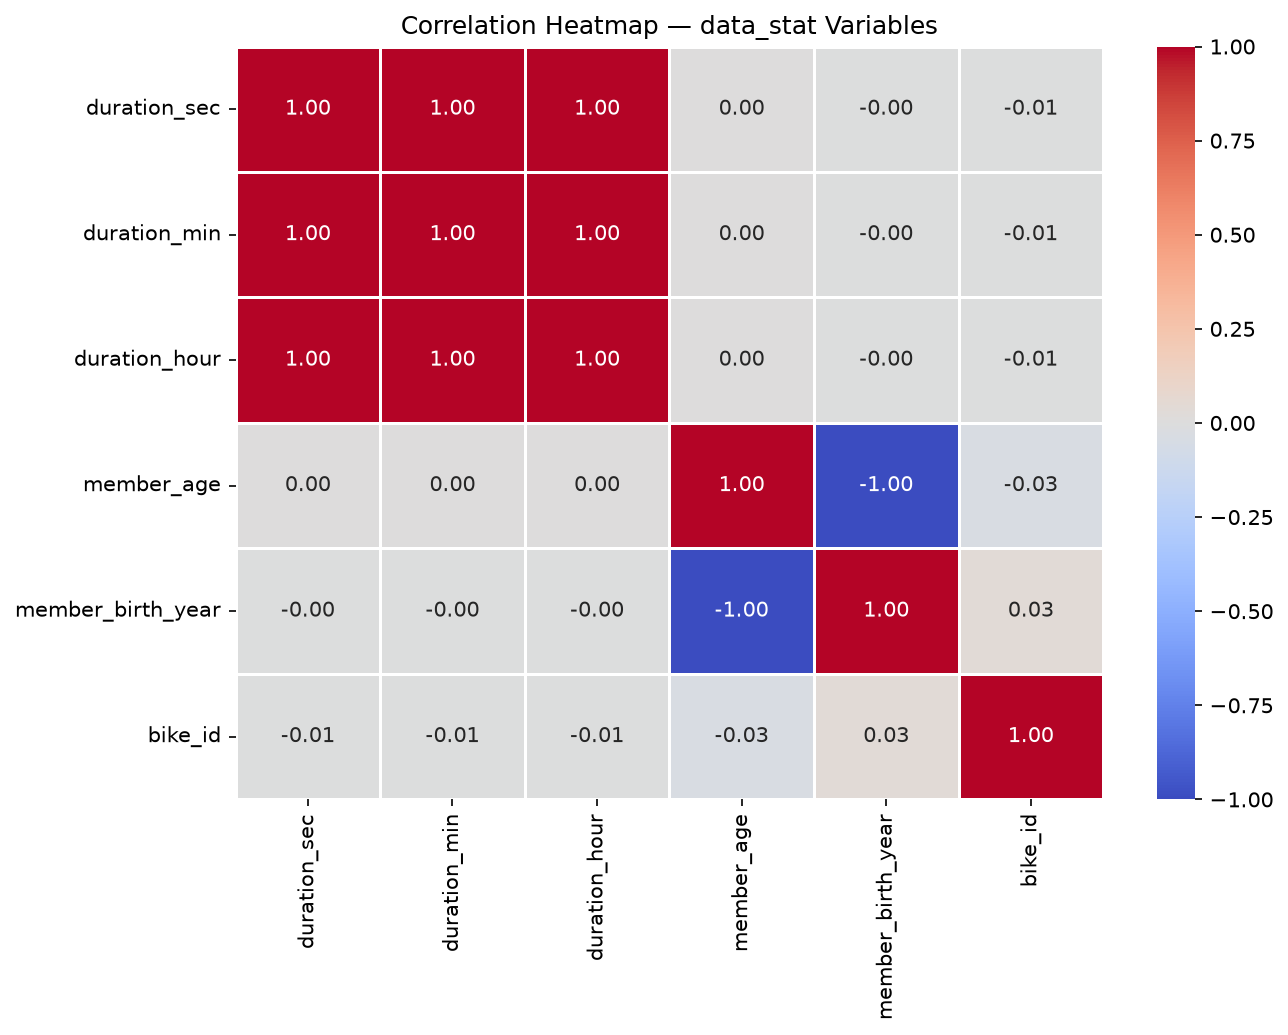

In [53]:

"""""This time I will use heatmap  to explain how Correlation between data_stat variables

in the dataset in more clear and specific percentage"""

# Make visualization to easy get insight
data_stat = data[['duration_sec','duration_min','duration_hour',
                  'member_age','member_birth_year','bike_id']]
plt.figure(figsize=(9,7), dpi=150)
sns.heatmap(data_stat.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=.5)
plt.title('Correlation Heatmap — data_stat Variables')
plt.tight_layout(); plt.show()



> ### <mark>The above charts show how Correlation between specific numeric variables in the dataset using heatmap plots  </mark>



**Actually the `heat map`  display the above ideas in clear percentages**



- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- There is a `negative  Correlation` between  member_birth_year  and age which normal.




- There is `no significant Correlation` for any variable with `bike_id `



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Conclusions</p>
# <a id="1100"> Conclusions </a>

#example
- Most users were Male.


- 

- 

- 



## limitation 
example
- We got missing data which we fix some of them .

- 
